In [1]:
%load_ext autoreload 
%autoreload 2
%reload_ext autoreload

# 1) At the very top of your script or notebook, before you import tensorflow:
import os
# suppress C++ INFO and WARNING logs (0 = all, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
    
import shap
from skimage.segmentation import slic
import tensorflow as tf
# force TF to retain *every* intermediate tensor (including control‐flow outputs)
tf.compat.v1.experimental.output_all_intermediates(True)

import numpy as np
from tensorflow.keras.models import load_model
from function import losses
from tensorflow.keras.layers import SpatialDropout2D, Dropout, Lambda
import time
# from function import shapelytest as stest
import keras_cv
from tqdm import tqdm

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Using TensorFlow backend


In [2]:

# 2) Suppress Python warnings (including deprecation warnings)
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# 3) Import and quiet TensorFlow’s Python logger
import logging

# this silences most tf.get_logger messages
tf.get_logger().setLevel(logging.ERROR)
# and this silences lower-level logs from the 'tensorflow' namespace
logging.getLogger('tensorflow').setLevel(logging.ERROR)


In [3]:
region_name = "CONUS"
experiment = "EX29"
week_lead = 2
ref_source = "GEFSv12"

checkpoint = f'checkpoints/{region_name}/Wk{week_lead}/Wk{week_lead}_{experiment}_regular_RZSM' if \
ref_source == 'GEFSv12' else f'checkpoints/{region_name}/Wk{week_lead}/Wk{week_lead}_{experiment}_ECMWF_regular_RZSM'
print(checkpoint)

checkpoints/CONUS/Wk2/Wk2_EX29_regular_RZSM


In [4]:
def select_n_channels(week_lead, ref_source):
    # return just the channel count
    if week_lead == 1 and ref_source == 'GEFSv12':
        return 13
    if week_lead == 2 and ref_source == 'GEFSv12':
        return 14
    if week_lead == 3 and ref_source == 'GEFSv12':
        return 5
    if week_lead == 4 and ref_source == 'GEFSv12':
        return 6
    if week_lead == 5 and ref_source == 'GEFSv12':
        return 7
    raise ValueError(f"Unsupported lead={week_lead}, source={ref_source}")

def return_data_dir(week_lead, ref_source,region_name):
    return (f'Data/model_npy_input_data/{region_name}/Wk{week_lead}_EX_input_data' if ref_source == 'GEFSv12' else  f'Data/{model_npy_input_data}/{region_name}/Wk{week_lead}_ECMWF_EX_input_data')


# 1a) Define a function that maps dropout → identity
def remove_dropout(layer):
    """
    Replace any SpatialDropout2D or Dropout layer with a no-op identity layer.
    All other layers are returned unchanged.
    """
    if isinstance(layer, (SpatialDropout2D, Dropout, keras_cv.layers.SqueezeAndExcite2D)):
        return Lambda(lambda x: x)
    return layer

# Load training and testing data

In [5]:
X_train = np.load(f'{return_data_dir(week_lead, ref_source,region_name)}/{experiment}_RZSM_training_input.npy')
X_test = np.load(f'{return_data_dir(week_lead, ref_source,region_name)}/{experiment}_RZSM_testing_input.npy')

print(X_train[0,:,:,0])

[[0.42408124 0.4734531  0.4485158  ... 0.43075514 0.42779055 0.42665896]
 [0.4341465  0.44612762 0.4472022  ... 0.         0.4281042  0.        ]
 [0.4442203  0.44606608 0.4603065  ... 0.42894194 0.4409061  0.45954335]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


# Load model and channel list information

In [6]:
#Add custom loss function
model = load_model(
    checkpoint,
    custom_objects={"crps2d_tf": losses.crps2d_tf},
    compile=False        # you don’t need to recompile if you’re just doing inference/SHAP
)

#feature channel names (predictors)
with open(f"channel_list_information/Wk{week_lead}/{experiment}_RZSM_channel_list.txt") as f:
    names = [line.strip() for line in f]
names = [s.split()[-1] for s in names]
print(names)

['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'RZSM_prediction_lead1', 'pwat_ref_lead2', 'spfh_ref_lead2', 'tmax_ref_lead2', 'diff_temp_ref_lead2', 'z200_ref_lead2']


# Load model weights and prune layers which are not compatible with Gradient Explainer

In [7]:
# 1) Save the original weights
print("▶ Saving original model weights…")
model.save_weights("/tmp/original_weights.h5")
print("✅ Weights saved to /tmp/original_weights.h5\n")

# 2) Clone & prune the model
def prune_layer(layer):
    # replace Dropout, SpatialDropout2D, and SqueezeAndExcite2D with identity
    if isinstance(layer, (Dropout, SpatialDropout2D, keras_cv.layers.SqueezeAndExcite2D)):
        return Lambda(lambda x: x, name=f"{layer.name}_pruned")
    return layer

print("▶ Cloning and pruning model…")
model_no_do = tf.keras.models.clone_model(
    model,
    clone_function=prune_layer
)
print("✅ Clone+prune complete.\n")

# 3) Load weights by name, skipping mismatches
print("▶ Loading matching weights into pruned model (by_name=True, skip_mismatch=True)…")
model_no_do.load_weights(
    "/tmp/original_weights.h5",
    by_name=True,
    skip_mismatch=True
)
print("✅ Weights loaded.\n")

# 4) Rebuild scalar-output model
print("▶ Building scalar-output model…")
final_head   = model_no_do.output[2]                        # 3rd head
scalar       = tf.reduce_mean(final_head, axis=[1,2,3])     # mean over H, W
scalar_model = tf.keras.Model(inputs=model_no_do.input, outputs=scalar)
print("✅ Scalar model built.")
print("   Inputs:",  scalar_model.input.shape)
print("   Output:",  scalar_model.output.shape)

▶ Saving original model weights…
✅ Weights saved to /tmp/original_weights.h5

▶ Cloning and pruning model…
✅ Clone+prune complete.

▶ Loading matching weights into pruned model (by_name=True, skip_mismatch=True)…
✅ Weights loaded.

▶ Building scalar-output model…
✅ Scalar model built.
   Inputs: (None, 48, 96, 14)
   Output: (None,)


# Quick test on a single sample

In [8]:
import time

def diagnostic_shap_test(
    scalar_model,
    background_data,
    X_data,
    sample_index=0,
    nsamples=1
):
    """
    Diagnostic SHAP test that:
      1) Prints shapes of inputs, background, and model I/O
      2) Computes and reports raw gradient min/max (or notes if None)
      3) Runs a tiny SHAP GradientExplainer and times it
      4) Prints SHAP summary stats

    Parameters
    ----------
    scalar_model : tf.keras.Model
        Maps (None, H, W, C) → (None,) scalar per sample.
    background_data : np.ndarray
        Background for SHAP, shape (N_bg, H, W, C).
    X_data : np.ndarray
        Data to explain, shape (N, H, W, C).
    sample_index : int
        Which sample in X_data to test.
    nsamples : int
        Number of nsamples to request from SHAP (set to 1 for a single pass).

    Returns
    -------
    dt : float
        Seconds taken by the SHAP call.
    shap_vals : np.ndarray
        The raw SHAP array for that single sample.
    """

    # 1) Shapes
    xb = X_data[sample_index:sample_index+1]
    bg = background_data[:1]
    print(f">>> Testing sample #{sample_index}: xb.shape = {xb.shape}")
    print(f">>> Using 1 background sample: bg.shape = {bg.shape}")
    print(f">>> scalar_model.input shape: {tuple(scalar_model.input.shape)}")
    print(f">>> scalar_model.output shape: {tuple(scalar_model.output.shape)}\n")

    # 2) Raw gradient check
    print(">>> Computing raw gradients with GradientTape …")
    x_tf = tf.convert_to_tensor(xb, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_tf)
        y = scalar_model(x_tf)  # shape [1]
    grads = tape.gradient(y, x_tf)
    if grads is None:
        print("    → Gradient is None: no gradient flow!")
    else:
        min_g = tf.reduce_min(grads).numpy()
        max_g = tf.reduce_max(grads).numpy()
        print(f"    → raw gradient min = {min_g:.3e}, max = {max_g:.3e}")
    print()

    # 3) SHAP call
    print(f">>> Building GradientExplainer(nsamples={nsamples}) …")
    expl = shap.GradientExplainer(scalar_model, bg)
    print(">>> Running explainer.shap_values(xb) …")
    t0 = time.time()
    shap_vals = expl.shap_values(xb, nsamples=nsamples)
    dt = time.time() - t0
    print(f"    → SHAP call took {dt:.2f}s")

    # 4) SHAP stats
    flat = np.array(shap_vals).reshape(-1)
    unique_vals = np.unique(np.round(flat, 6))
    mean_abs    = np.mean(np.abs(flat))
    print(f"    → unique SHAP (rounded 1e-6): {unique_vals[:5]} … {unique_vals[-5:]}")
    print(f"    → mean |SHAP| = {mean_abs:.3e}\n")

    return dt, shap_vals


# 4) Prepare a *background* dataset from TRAINING data
bg_idx     = np.random.choice(X_train.shape[0], size=5, replace=False)
background = X_train[bg_idx, : ,: , :select_n_channels(week_lead, ref_source)]   # shape (size, 48, 96, 14)

# Example usage:
dt, sv = diagnostic_shap_test(scalar_model, background, X_test, sample_index=0, nsamples=1)


>>> Testing sample #0: xb.shape = (1, 48, 96, 14)
>>> Using 1 background sample: bg.shape = (1, 48, 96, 14)
>>> scalar_model.input shape: (None, 48, 96, 14)
>>> scalar_model.output shape: (None,)

>>> Computing raw gradients with GradientTape …
    → raw gradient min = -7.551e-03, max = 2.388e-02

>>> Building GradientExplainer(nsamples=1) …
>>> Running explainer.shap_values(xb) …


`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


    → SHAP call took 2.82s
    → unique SHAP (rounded 1e-6): [-0.001246 -0.000671 -0.000589 -0.000519 -0.000364] … [0.000283 0.000288 0.000294 0.000299 0.000686]
    → mean |SHAP| = 2.605e-06



# Gradient Explainer


### select the size of the training set background (K)

In [9]:
C=select_n_channels(week_lead, ref_source)
K = 250 #Pick number of training set background samples
N = X_train.shape[0]

In [13]:


# Prepare a *background* dataset from TRAINING data
bg_idx     = np.random.choice(N, size=K, replace=False)
background = X_train[bg_idx, : ,: , :C]   # shape (size, 48, 96, 14)

# choose how many test samples to explain
# can do all of X_test, or just a subset if it’s large
N_test     = X_test.shape[0]
to_explain = X_test[:N_test, : ,: , :C]    # e.g. shape (N_test,48,96,C)


In [14]:

explainer = shap.GradientExplainer(scalar_model, background)
# or, if you prefer and have TF1‐style graph mode:
# explainer = shap.DeepExplainer(scalar_model, background)


# 2) loop in batches with tqdm
batch_size = 10
shap_list = []
N = to_explain.shape[0]

for start in tqdm(range(0, N, batch_size), desc="Computing SHAP batches"):
    end   = min(start + batch_size, N)
    batch = to_explain[start:end]
    sv    = explainer.shap_values(batch)
    shap_list.append(sv)

# 3) stitch back together
shap_values = np.concatenate(shap_list, axis=0)

Computing SHAP batches: 100%|██████████| 115/115 [16:49<00:00,  8.78s/it]


In [16]:
shap_values.shape

(1144, 48, 96, 14)

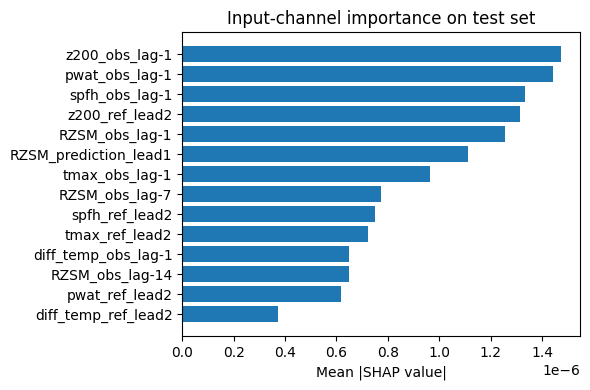

In [17]:
import matplotlib.pyplot as plt

# mean |SHAP| over samples, height & width → per‐channel
imp = np.mean(np.abs(shap_values), axis=(0,1,2))  # shape (C,)
names = names[:C]                         # your list of length C

# sort & plot
order = np.argsort(imp)
plt.figure(figsize=(6,4))
plt.barh([names[i] for i in order], imp[order])
plt.xlabel("Mean |SHAP value|")
plt.title("Input‐channel importance on test set")
plt.tight_layout()
plt.show()


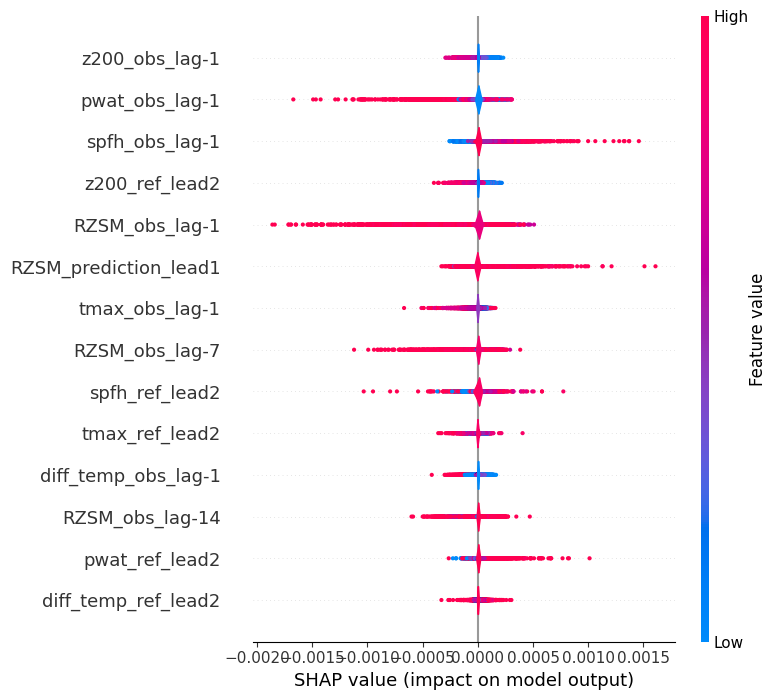

In [27]:
# flatten out samples×pixels → (N_test*48*96, C)
sv_flat = shap_values.reshape(-1, C)

# summary plot (requires the flattened input X too, for coloring)
X_flat  = to_explain.reshape(-1, C)
shap.summary_plot(sv_flat, X_flat, feature_names=names, plot_type="violin")


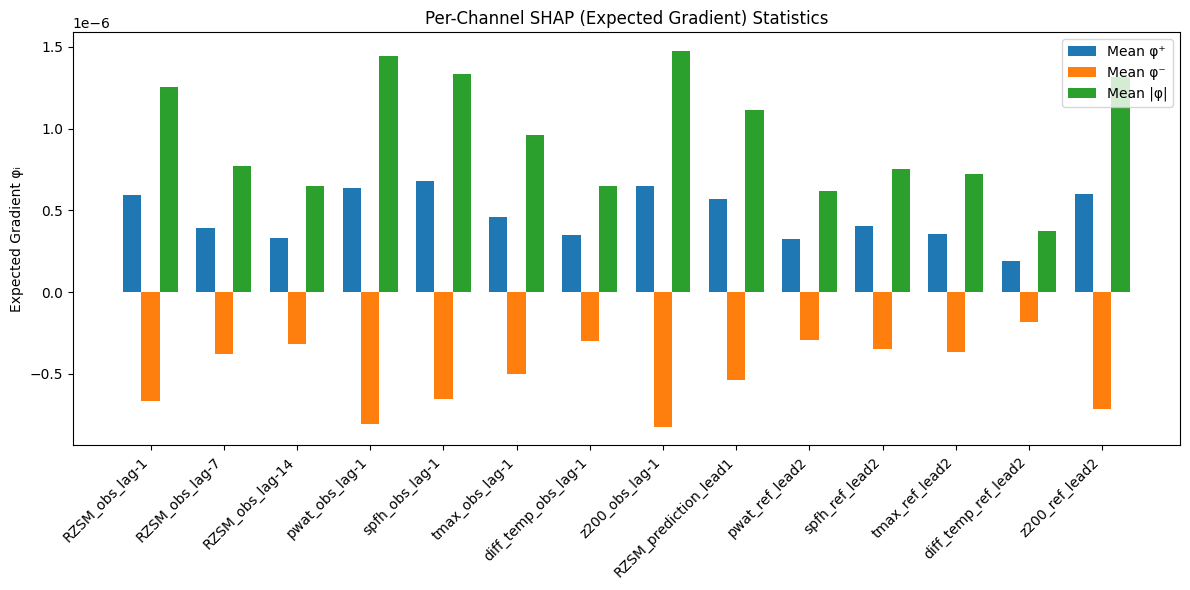

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_channel_expected_gradients(shap_values, channel_names):
    """
    shap_values: np.ndarray, shape (N_samples, H, W, C)
    channel_names: list of length C
    """

    # 1) collapse sample & spatial dims → (N*H*W, C)
    N, H, W, C = shap_values.shape
    flat = shap_values.reshape(-1, C)

    # 2) compute per-channel stats
    mean_pos = np.mean(np.clip(flat,    0, None), axis=0)  # only positives
    mean_neg = np.mean(np.clip(flat, None, 0), axis=0)    # only negatives
    mean_abs = np.mean(np.abs(flat),       axis=0)       # magnitudes

    # 3) plot
    x = np.arange(C)
    width = 0.25
    fig, ax = plt.subplots(figsize=(12,6))

    ax.bar(x - width, mean_pos, width, label="Mean φ⁺")
    ax.bar(x,         mean_neg, width, label="Mean φ⁻")
    ax.bar(x + width, mean_abs, width, label="Mean |φ|")

    ax.set_xticks(x)
    ax.set_xticklabels(channel_names, rotation=45, ha="right")
    ax.set_ylabel("Expected Gradient φᵢ")
    ax.set_title("Per-Channel SHAP (Expected Gradient) Statistics")
    ax.legend()
    plt.tight_layout()
    plt.show()

# usage:
plot_channel_expected_gradients(shap_values, names)


Top 5 features by mean |SHAP|:
  z200_obs_lag-1      : 1.474e-06
  pwat_obs_lag-1      : 1.443e-06
  spfh_obs_lag-1      : 1.334e-06
  z200_ref_lead2      : 1.313e-06
  RZSM_obs_lag-1      : 1.256e-06


<Figure size 600x400 with 0 Axes>

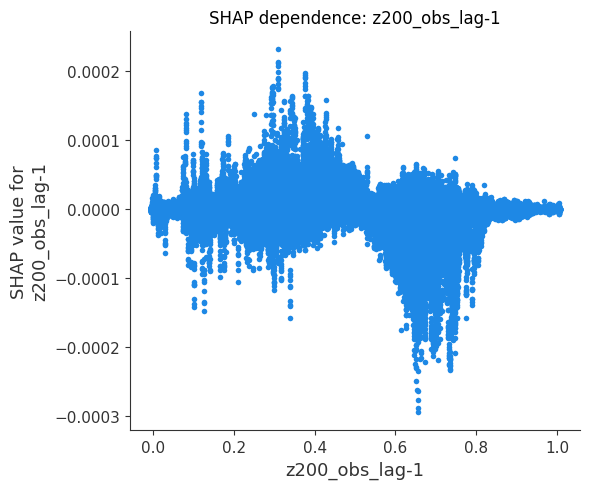

<Figure size 600x400 with 0 Axes>

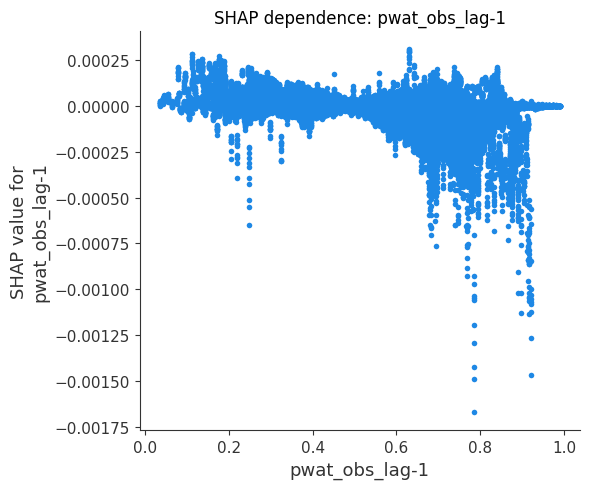

<Figure size 600x400 with 0 Axes>

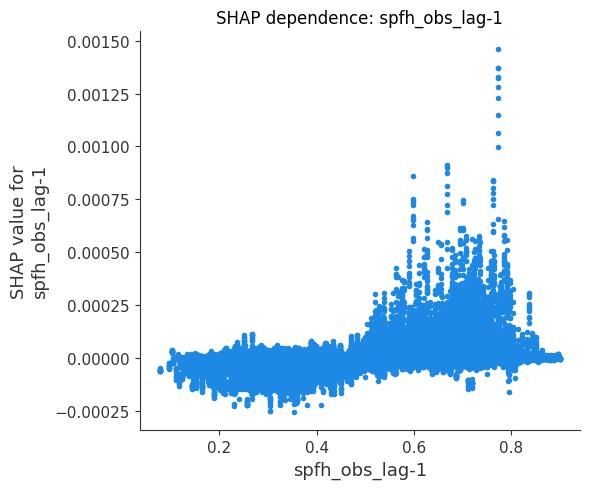

<Figure size 600x400 with 0 Axes>

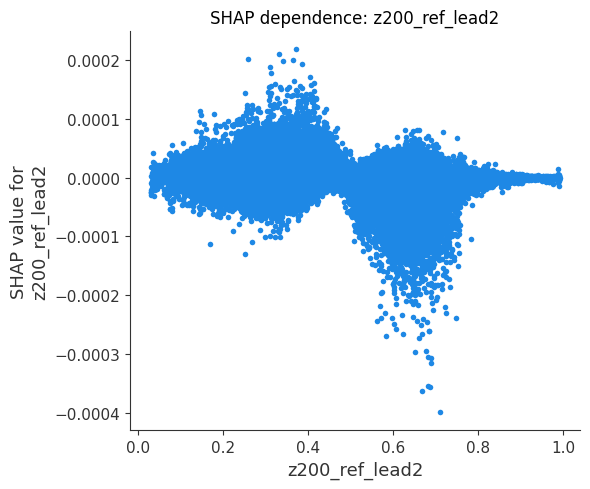

<Figure size 600x400 with 0 Axes>

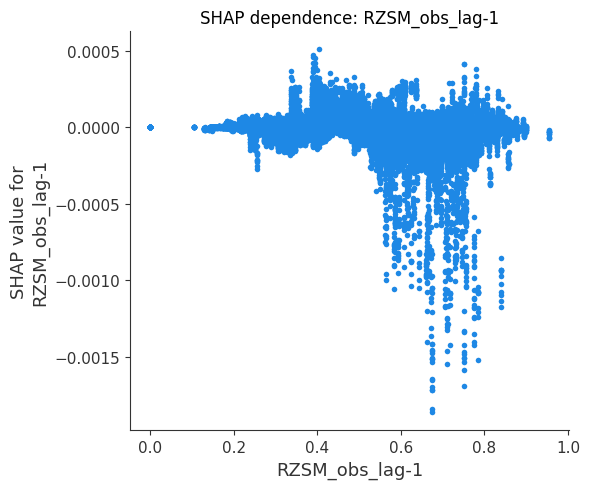

In [26]:
# 1) Flatten samples×pixels → (N_total, C)
N, H, W, C = shap_values.shape
sv_flat = shap_values.reshape(-1, C)
X_flat  = to_explain.reshape(-1, C)   # or X_test if that’s your array

# 2) Compute mean absolute importance and pick top 5
importance = np.mean(np.abs(sv_flat), axis=0)      # shape (C,)
top5_idx   = np.argsort(-importance)[:5]           # indices of top 5
top5_names = [names[i] for i in top5_idx]  # their names

print("Top 5 features by mean |SHAP|:")
for i, name in zip(top5_idx, top5_names):
    print(f"  {name:20s}: {importance[i]:.3e}")

# 3) Dependence plots for those top 5
for idx, name in zip(top5_idx, top5_names):
    plt.figure(figsize=(6,4))
    # you can pass the feature index or name; here we use name
    shap.dependence_plot(
        name,            # feature to plot
        sv_flat,         # shap values matrix
        X_flat,          # original feature matrix
        feature_names=names,
        interaction_index=None,  # or let SHAP pick the strongest interaction
        show=False
    )
    plt.title(f"SHAP dependence: {name}")
    plt.tight_layout()
    plt.show()

In [ ]:
stop

In [ ]:
names

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# importance_per_channel: your array of shape (14,)
# names: list of 14 channel names, in the same order

# Sort channels by importance
idx_sorted = np.argsort(importance_per_channel)
sorted_imp = importance_per_channel[idx_sorted]
sorted_names = [names[i] for i in idx_sorted]

plt.figure(figsize=(8,6))
plt.barh(sorted_names, sorted_imp)
plt.xlabel("Mean |SHAP value|")
plt.title("Global feature importance (per input channel)")
plt.tight_layout()
plt.show()


# Gradient Explainer

In [ ]:
model.input

In [ ]:
# 1b) Clone your existing model, stripping out dropouts
model_no_do = tf.keras.models.clone_model(
    model,
    clone_function=remove_dropout
)
# copy over weights
model_no_do.set_weights(model.get_weights())

# 1c) Rebuild the scalar-output model on the cleaned model
final_head   = model_no_do.output[2]                         # pick your head
scalar       = tf.reduce_mean(final_head, axis=[1,2,3])      # mean over H,W
scalar_model = tf.keras.Model(inputs=model_no_do.input, outputs=scalar)


# 4) Prepare a *background* dataset from TRAINING data
bg_idx     = np.random.choice(X_train.shape[0], size=50, replace=False)
background = X_train[bg_idx, : ,: , :n_ch]   # shape (50, 48, 96, 14)

# 5) Create a GradientExplainer on the scalar-output model
explainer = shap.GradientExplainer(scalar_model, background)

# 6) Explain a batch of TEST samples
X_batch    = X_test[:10, : ,: , :n_ch]
shap_values = explainer.shap_values(X_batch)
# `shap_values` is now a NumPy array of shape (10, 48, 96, 14)

# 7) Aggregate to get a single importance per channel:
#    mean absolute value over samples, height & width
importance_per_channel = np.mean(np.abs(shap_values), axis=(0,1,2))
# → shape (14,)

# 8) (Optional) if you have your 14 channel names loaded:
#    names = ["pwat_eatm", "spfh_2m", …]  length 14
for name, imp in zip(names, importance_per_channel):
    print(f"{name:12s}: {imp:.5f}")

In [ ]:
explainer   = shap.DeepExplainer(scalar_model, background)
shap_values = explainer.shap_values(X_batch)          # shape (N,48,96,14)
importance  = np.mean(np.abs(shap_values), axis=(0,1,2))


In [ ]:
# 1) determine how many channels to slice out
n_ch = select_n_channels(week_lead, ref_source)
print(f'Number of features is {n_ch}')

# 2) grab a sample from your data loader / array
#    Suppose your full training data is `X_train` of shape (N,48,96,14)
#    and you want the first example:

x_np = X_train[0, :, :, :n_ch]   # now x_np.shape == (48, 96, 5)

shape = x_np.shape 
print("explaining sample with shape:", x_np.shape)

# 3) compute super-pixels on that actual array
segments = slic(x_np, n_segments=200, compactness=10)

#. Role of a SHAP Masker
#A masker in SHAP defines how features are “hidden” or “masked out” when computing approximate Shapley values. For image data, masking means replacing regions of the input with some baseline or “uninformative” value, so that we can measure how the model’s output changes when each region is “missing.”

# 4) build the SHAP masker
#masker = shap.maskers.Image("inpaint_telea", shape)
masker = shap.maskers.Image(0.0, x_np.shape) # mask_value = 0.0 means "fill masked regions with zero"

In [ ]:
# counter factual experiments/explainer.. could try this approach..
#sensitivity analysis... how the output is responding to the changes in the input... like a sensitivity experiment

#... if we change any one one of those variables, then they can be 

In [ ]:
import tensorflow as tf

class MultiHeadWrapper(tf.keras.Model):
    """
    A Keras model wrapper that transforms a UNet++ with three regression heads
    into a single-output model whose predictions are a concatenated flat vector.

    This is useful for SHAP explainers: by flattening and concatenating
    all three output maps into one vector, you get attributions for every
    regression head in one pass.

    Attributes
    ----------
    unetpp : tf.keras.Model
        The original UNet++ model that returns three outputs when called.

    Methods
    -------
    call(x)
        Runs a forward pass through UNet++, flattens each output map,
        and concatenates them into a single 2D tensor of shape [B, H*W*3].
    """

    def __init__(self, unetpp):
        """
        Initialize the wrapper.

        Parameters
        ----------
        unetpp : tf.keras.Model
            A UNet++ model whose `call(x, training=False)` returns a tuple
            of three tensors, each of shape [B, H, W, 1].
        """
        super().__init__()
        self.unetpp = unetpp

    def call(self, x):
        """
        Forward pass that flattens and concatenates all three UNet++ outputs.

        Parameters
        ----------
        x : tf.Tensor
            Input batch tensor of shape [B, H, W, C].

        Returns
        -------
        tf.Tensor
            A 2D tensor of shape [B, H*W*3], where each slice along axis=1
            is the flattened regression map from one of the three heads.
        """
        # 1) Run the UNet++ model in inference mode
        #    expected to return a tuple of 3 tensors: (o1, o2, o3)
        o1, o2, o3 = self.unetpp(x, training=False)  
        #    each 'oi' has shape [B, H, W, 1]

        # 2) Determine the batch size dynamically (will be a scalar tensor)
        b = tf.shape(o1)[0]  

        # 3) Flatten each output map:
        #    reshape from [B, H, W, 1] → [B, H*W]
        #    The '-1' in the shape tells TF to infer H*W*1 automatically.
        flat1 = tf.reshape(o1, (b, -1))
        flat2 = tf.reshape(o2, (b, -1))
        flat3 = tf.reshape(o3, (b, -1))

        # 4) Concatenate along the feature axis:
        #    [B, H*W] + [B, H*W] + [B, H*W] → [B, 3 * (H*W)]
        return tf.concat([flat1, flat2, flat3], axis=1)


In [ ]:
# pick e.g. 50 examples from your training set as background
bg_idx = np.random.choice(len(X_train), size=50, replace=False)
background = X_train[bg_idx, : ,: , :n_ch]

explainer = shap.Explainer(
    wrapped, 
    masker, 
    algorithm="partition", 
    background=background)


In [ ]:
B=20
# explain first B examples from your test set
x_batch = X_test[:B, : ,: , :n_ch]
shap_vals = explainer(x_batch, max_evals=2048)


In [ ]:
!pip install skimage




In [ ]:
class SegmentationWrapper(torch.nn.Module):
    def __init__(self, unetpp):
        super().__init__()
        self.model = unetpp.eval()
    def forward(self, x):
        # returns flattened per-pixel class scores, or aggregated scores
        logits = self.model(x)               # shape [B,C,H,W]
        # e.g. sum over classes, or focus on one class
        return logits[:, target_class, :, :].view(x.shape[0], -1)


In [ ]:
#Tensorflow RT things
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
tf.config.optimizer.set_jit(True) # Enable XLA.

In [ ]:
global region_name,testing_scenario,save_loss_name
region_name = 'CONUS' #['australia','CONUS', 'china']

global ref_source,reforecast_input,obs_source
ref_source = 'GEFSv12' #['GEFSv12','ECMWF']
obs_source='ERA5' #['GLEAM','ERA5']

In [ ]:
global final_testing_year
final_testing_year = 2019

    
'''Make sure to fill in this information depending on what test we are doing'''
make_single_prediction_from_model_for_testing=True
make_additional_predictions_from_model_for_testing = True
permutation_test_graphs_create=True
bias_correction_predict = False


global RZSM_or_Tmax_or_both, num_predictions_testing, num_train_val_predictions
RZSM_or_Tmax_or_both = 'RZSM' # for getting the predictor from either RZSM and Tmax ('both') or only RZSM ('RZSM')
num_predictions_testing = 25
num_train_val_predictions=10

#for permutation plot
max_RZSM_value,max_tmax_value = 0.05,5

#set for the larger memeory ones
# os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'


In [ ]:
EX0,EX1,EX2,EX3,EX4,EX5,EX6,EX7,EX8,EX9,EX10,EX11,EX12,EX13,EX14,EX15,EX16,EX17,EX18,EX19,EX20,EX21,EX22,EX23,EX24,EX25,EX27,EX28,EX29 = experimentType.return_experiment_dictionaries(region_name)

# Choose different loss and architecture configurations

In [ ]:
#First just re-save the new density value into a new file (it's convoluted but it works)
# denseValue.return_dense_value_file(region_name, 0.5) #can chooose 0.5 or 0.8 as the alpha coefficient

testing_scenario = 'regular' #['mse','dense', 'regular', 'transformer', 'super_pixel', 'attention', 'denseLarge']
assert testing_scenario in ['regular', 'mse'], "You must put the testing_scenario as 'regular' or 'mse' for final manuscript results'"

global save_loss_name, loss_fn
if ref_source=='ECMWF':
    save_loss_name, loss_fn = losses.return_ECMWF_loss_name_and_function(testing_scenario)
else:
    save_loss_name, loss_fn = losses.return_GEFSv12_loss_name_and_function(testing_scenario)


# This script will load data based on specific lead times that we want to experiment with and what Experiments we choose to run

# Week 1 (lead index 6 of the forecast)

| Ex. Number/Name | Obs. RZSM Inputs | Obs. Other Inputs                    | UNET predicted Inputs (N>=2)     |Reforecast Inputs| Prediction Lead Week/Variables | Activation function | Loss function | Batch size |
| ----------------| -----------------| ------------------------------------ | -------------------      |--------          | -------------------| ---------------------| ------------------------| ------------|
| 0 - EX0         | None             | None                                 | None                     | RZSM, Wk 1-N| Wk N     -  RZSM |              Relu             | CRPS experimental| 66
| 1 - EX1         | Wk. lags 1-3    | pwat,spfh,tmax,z200,diff_temp lags 1-3 | RZSM Wk 1-N |        None |  Wk N     -  RZSM |             Relu             | CRPS experimental | 66
| 2 - EX2         | Wk. lags 1-6   | pwat,spfh,tmax,z200,diff_temp lags 1-3  | RZSM Wk 1-N          |  None |  Wk N     -  RZSM |       Relu             | CRPS experimental| 66
| 3 - EX3         | Wk. lags 1-9    | pwat,spfh,tmax,z200,diff_temp lags 1-3 | RZSM Wk 1-N         |  None |  Wk N     -  RZSM |       Relu             | CRPS experimental| 66
| 4 - EX4         | Wk. lags 1-12    | pwat,spfh,tmax,z200,diff_temp lags 1-3| RZSM Wk 1-N         |  None |  Wk N     -  RZSM |      Relu             | CRPS experimental| 66
| 5 - EX5         | Wk. lags 1-3   | None                                   | None                   | RZSM, week N | Wk N     -  RZSM  |         Relu             | CRPS experimental| 66
| 6 - EX6         | Wk. lags 1-6   | None                                     | None                   |RZSM, week N  | Wk N     -  RZSM  |        Relu             | CRPS experimental| 66
| 7 - EX7         | Wk. lags 1-9    | None                                | None                   |RZSM, week N  | Wk N     -  RZSM  |         Relu             | CRPS experimental |66
| 8 - EX8         | Wk. lags 1-12    | None                                  | None                   |RZSM, week N  | Wk N     -  RZSM |         Relu             | CRPS experimental | 66
| 9 - EX9         | Wk. lags 1-3    |pwat,spfh,tmax,z200,diff_temp lags 1-3  | RZSM Wk 1-N                  |RZSM  week N  | Wk N     -  RZSM  |         Relu             | CRPS experimental| 66
| 10 - EX10       | Wk. lags 1-6    |pwat,spfh,tmax,z200,diff_temp  lags 1-3 | RZSM Wk 1-N                  |RZSM  week N  |Wk N     -  RZSM   |         Relu             | CRPS experimental| 66
| 11 - EX11       | Wk. lags 1-9    |pwat,spfh,tmax,z200,diff_temp  lags 1-3 | RZSM Wk 1-N                  |RZSM  week N  | Wk N     -  RZSM  |         Relu             | CRPS experimental| 66
| 12 - EX12       | Wk. lags 1-12   |pwat,spfh,tmax,z200,diff_temp lags 1-3  | RZSM Wk 1-N                  |RZSM  week N  | Wk N     -  RZSM  |         Relu             | CRPS experimental| 66
| 13 - EX13       | None             | None                                 | None                     | RZSM week N| Wk N     -  RZSM |              Relu             | CRPS experimental| 66
| 14 - EX14         | Wk. lags 1-3    | pwat,spfh,tmax,z200,diff_temp lags 1-3 | None |        None |  Wk N     -  RZSM |             Relu             | CRPS experimental | 66
| 15 - EX15         | Wk. lags 1-6   | pwat,spfh,tmax,z200,diff_temp lags 1-3  | None             |  None |  Wk N     -  RZSM |       Relu             | CRPS experimental| 66
| 16 - EX16         | Wk. lags 1-9    | pwat,spfh,tmax,z200,diff_temp lags 1-3 | None            |  None|  Wk N     -  RZSM |       Relu             | CRPS experimental| 66
| 17 - EX17        | Wk. lags 1-12    | pwat,spfh,tmax,z200,diff_temp lags 1-3| None            |  None|  Wk N     -  RZSM |      Relu             | CRPS experimental| 66
| 18 - EX18         | Wk. lags 1-3   | None                                   | RZSM Wk 1-N                 | RZSM, week N | Wk N     -  RZSM  |         Relu             | CRPS experimental| 66
| 19 - EX19         | Wk. lags 1-6   | None                                     | RZSM Wk 1-N                  |RZSM, week N  | Wk N     -  RZSM  |        Relu             | CRPS experimental| 66
| 20 - EX20         | Wk. lags 1-9    | None                                | RZSM Wk 1-N                  |RZSM, week N  | Wk N     -  RZSM  |         Relu             | CRPS experimental |66
| 21 - EX21         | Wk. lags 1-12    | None                                  | RZSM Wk 1-N                   |RZSM, week N  | Wk N     -  RZSM |         Relu             | CRPS experimental | 66
| 22 - EX22         | Wk. lags 1-3   | None                                   | None                   | None | Wk N     -  RZSM  |         Relu             | CRPS experimental| 66
| 23 - EX23         | Wk. lags 1-6   | None                                     | None                   |None  | Wk N     -  RZSM  |        Relu             | CRPS experimental| 66
| 24 - EX24         | Wk. lags 1-9    | None                                | None                   |None  | Wk N     -  RZSM  |         Relu             | CRPS experimental |66
| 25 - EX25         | Wk. lags 1-12    | None                                  | None                   |None  | Wk N     -  RZSM |         Relu             | CRPS experimental | 66
| 26 - EX26         | None    | None                                  | None                   |Wk 1-N (choose best models)  | Wk N     -  RZSM |         Relu             | CRPS experimental | 66
| 27 - EX27         | Wk. lags 1-3    |pwat,spfh,tmax,z200,diff_temp lags 1-3  |  None                   |Wk1 RZSM,tmax, diff_temp, z200, pwat, spfh  | Wk N     -  RZSM  |         Relu             | CRPS experimental| 66 (like EX9)
| 28 - EX28         | Wk. lags 1-6    |pwat,spfh,tmax,z200,diff_temp lags 1-3  |  None                   |Wk1 RZSM,tmax, diff_temp, z200, pwat, spfh  | Wk N     -  RZSM  |         Relu             | CRPS experimental| 66 (like EX10)

# EX 1-4 - Testing if the prediction of previous week adds value (but don't include the current week that is trying to be predicted). Observation driven but with a prediction.
# EX 14-17 - Testing if the prediction of previous week adds value (but don't include the current week that is trying to be predicted). Purely observation driven.
# EX 5-8 - Testing if adding other observations (pwat, spfh, etc) has an increase or decrease in skill.
# EX 18-21 - Seeing if adding the previous week gains additional skill
# EX 22-25 - Purely observation driven. Only soil moisture.

In [ ]:
input_directory = f'Data/model_npy_input_data/{region_name}/Model_input_data' #For inputs into the model
verification_directory = f'Data/model_npy_input_data/{region_name}/Verification_data' #For observation verification
start_of_forecast_init = '2000-01-05'
end_of_forecast_init = '2019-12-25'

global training_size_shape
training_size_shape = np.array((9185,48,96))

global validation_testing_size_shape
validation_testing_size_shape = np.array((1144,48,96))

'''This decides how many lag weeks we have for data such as pwat, z200, tmax, etc'''
global observation_lag_list_not_RZSM
#This is for observations pwat, z200, spfh, tmax, diff_temp variables used as predictors
#These are the day lags which were already computed as the 7-day rolling mean

observation_lag_list_not_RZSM = [-1,-7,-14] 

In [ ]:
#For testing
# lead=1
# num_lags_obs_RZSM = 6
# include_lags_obs_pwat_spfh_tmax = True
# include_reforecast_or_not=True
# deep_supervision = True
# initial_learning_rate = 0.0001
# beta_1 = 0.9
# batch_size=66
# epochs=1
# shuffle=False
# kernel_norm =  None
# patience=10

In [ ]:
def make_UNET_stacked_inputs(lead, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, include_reforecast_or_not, 
                             observation_lag_list_not_RZSM, lag_integer_list, input_directory,training_size_shape,
                             validation_testing_size_shape,experiment_name,RZSM_or_Tmax_or_both,addtl_experiment,
                             experiment_test,region_name,experiment_name_out,obs_source,ref_source):
    
    
    #Set restrictions. For EX0, we only want to bias correct the forecasts with week lead 1 RZSM and tmax
    if experiment_name == 'EX0' or experiment_name == 'EX13':
        
        #Step 1 load data 
        print(f'\nWorking on setting up data for Experiment {experiment_name} for lead {lead}\n')
        
        final_input_train, final_input_validation, final_input_testing,channel_list =  loadData.load_all_data_EX0(lead=lead, 
                                                                                                                  num_lags_obs_RZSM=num_lags_obs_RZSM, 
                                                                                                                  include_lags_obs_pwat_spfh_tmax=include_lags_obs_pwat_spfh_tmax,
                                                                                                                  include_reforecast_or_not=include_reforecast_or_not,
                                                                                                                  observation_lag_list_not_RZSM=observation_lag_list_not_RZSM,
                                                                                                                  lag_integer_list=lag_integer_list, 
                                                                                                                  input_directory=input_directory,
                                                                                                                  training_size_shape=training_size_shape,
                                                                                                                  validation_testing_size_shape=validation_testing_size_shape,
                                                                                                                  RZSM_or_Tmax_or_both=RZSM_or_Tmax_or_both,
                                                                                                                  addtl_experiment=addtl_experiment,
                                                                                                                  experiment_test=experiment_test,
                                                                                                                  final_testing_year=final_testing_year,
                                                                                                                  ref_source=ref_source,obs_source=obs_source)

        print(f'\nInput channels will be only week 1 Tmax and RZSM through the current lead {lead} which are also going to be predicted. There are no observations in this experiment\n')
        
        print('Done')
        
        
    
    ############################################### EXPERIMENTS 1-4 ####################################################################################
    elif experiment_name in ['EX1','EX2','EX3','EX4','EX14','EX15','EX16','EX17']:

        print(f'\nWorking on setting up data for Experiment {experiment_name} for lead {lead}\n')
        

        final_input_train, final_input_validation, final_input_testing,channel_list = loadData.load_all_data_EX1_EX2_EX3_EX4_after_week_0(lead=lead, 
                                                                                                                  num_lags_obs_RZSM=num_lags_obs_RZSM, 
                                                                                                                  include_lags_obs_pwat_spfh_tmax=include_lags_obs_pwat_spfh_tmax,
                                                                                                                  include_reforecast_or_not=include_reforecast_or_not,
                                                                                                                  observation_lag_list_not_RZSM=observation_lag_list_not_RZSM,
                                                                                                                  lag_integer_list=lag_integer_list, 
                                                                                                                  input_directory=input_directory,
                                                                                                                  training_size_shape=training_size_shape,
                                                                                                                  validation_testing_size_shape=validation_testing_size_shape,
                                                                                                                  RZSM_or_Tmax_or_both=RZSM_or_Tmax_or_both,
                                                                                                                  addtl_experiment=addtl_experiment,
                                                                                                                  experiment_test=experiment_test,
                                                                                                                  final_testing_year=final_testing_year,
                                                                                                                  ref_source=ref_source,
                                                                                                                  obs_source=obs_source,
                                                                                                                  experiment_name=experiment_name,
                                                                                                                  experiment_name_out=experiment_name_out)
    
                
        print('Done')
        
        
    
    ############################################### EXPERIMENTS 5-8 ####################################################################################
    elif experiment_name in ['EX5','EX6','EX7','EX8','EX18','EX19','EX20','EX21','EX22','EX23','EX24','EX25']:

        print(f'\nWorking on setting up data for Experiment {experiment_name} for lead {lead}\n')
        
        # #Step 1 load data 
        # if addtl_experiment == False:
        #     final_input_train, final_input_validation, final_input_testing,channel_list = loadData.load_all_data_EX5_EX6_EX7_EX8(lead, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, 
        #                                                                                                    include_reforecast_or_not, observation_lag_list_not_RZSM, lag_integer_list,
        #                                                                                                    input_directory,training_size_shape,validation_testing_size_shape,RZSM_or_Tmax_or_both,
                                                                                                                                   # region_name=region_name)
        # else:
        final_input_train, final_input_validation, final_input_testing,channel_list = loadData.load_all_data_EX5_EX6_EX7_EX8_experiments(lead=lead, 
                                                                                                                  num_lags_obs_RZSM=num_lags_obs_RZSM, 
                                                                                                                  include_lags_obs_pwat_spfh_tmax=include_lags_obs_pwat_spfh_tmax,
                                                                                                                  include_reforecast_or_not=include_reforecast_or_not,
                                                                                                                  observation_lag_list_not_RZSM=observation_lag_list_not_RZSM,
                                                                                                                  lag_integer_list=lag_integer_list, 
                                                                                                                  input_directory=input_directory,
                                                                                                                  training_size_shape=training_size_shape,
                                                                                                                  validation_testing_size_shape=validation_testing_size_shape,
                                                                                                                  RZSM_or_Tmax_or_both=RZSM_or_Tmax_or_both,
                                                                                                                  addtl_experiment=addtl_experiment,
                                                                                                                  experiment_test=experiment_test,
                                                                                                                  final_testing_year=final_testing_year,
                                                                                                                  ref_source=ref_source,
                                                                                                                  obs_source=obs_source,
                                                                                                                  experiment_name=experiment_name,
                                                                                                                  experiment_name_out=experiment_name_out)

        print('Done')
        
        
    
    ############################################### EXPERIMENTS 9-12 ####################################################################################
    elif (experiment_name == 'EX9') or (experiment_name == 'EX10') or (experiment_name == 'EX11') or (experiment_name == 'EX12') or (experiment_name == 'EX27') or (experiment_name == 'EX28'):
        
        print(f'\nWorking on setting up data for Experiment {experiment_name} for lead {lead}\n')

        final_input_train, final_input_validation, final_input_testing,channel_list = loadData.load_all_data_EX9_EX10_EX11_EX12_after_week_0(lead=lead, 
                                                                                                                  num_lags_obs_RZSM=num_lags_obs_RZSM, 
                                                                                                                  include_lags_obs_pwat_spfh_tmax=include_lags_obs_pwat_spfh_tmax,
                                                                                                                  include_reforecast_or_not=include_reforecast_or_not,
                                                                                                                  observation_lag_list_not_RZSM=observation_lag_list_not_RZSM,
                                                                                                                  lag_integer_list=lag_integer_list, 
                                                                                                                  input_directory=input_directory,
                                                                                                                  training_size_shape=training_size_shape,
                                                                                                                  validation_testing_size_shape=validation_testing_size_shape,
                                                                                                                  RZSM_or_Tmax_or_both=RZSM_or_Tmax_or_both,
                                                                                                                  addtl_experiment=addtl_experiment,
                                                                                                                  experiment_test=experiment_test,
                                                                                                                  final_testing_year=final_testing_year,
                                                                                                                  ref_source=ref_source,
                                                                                                                  obs_source=obs_source,
                                                                                                                  experiment_name=experiment_name,
                                                                                                                  experiment_name_out=experiment_name_out)
    elif (experiment_name == 'EX26'):

        print(f'\nWorking on setting up data for Experiment {experiment_name} for lead {lead}\n')

        final_input_train, final_input_validation, final_input_testing,
        channel_list = loadData.load_only_predictions_EX26(lead, input_directory,training_size_shape,validation_testing_size_shape,RZSM_or_Tmax_or_both,experiment_name,region_name,
                               experiment_name_out)
        print('Done')


    elif (experiment_name == 'EX29'):
        
        print(f'\nWorking on setting up data for Experiment {experiment_name} for lead {lead}\n')

        final_input_train, final_input_validation, final_input_testing,channel_list = loadData.load_all_data_EX29_after_week_0(lead=lead, 
                                                                                                                  num_lags_obs_RZSM=num_lags_obs_RZSM, 
                                                                                                                  include_lags_obs_pwat_spfh_tmax=include_lags_obs_pwat_spfh_tmax,
                                                                                                                  include_reforecast_or_not=include_reforecast_or_not,
                                                                                                                  observation_lag_list_not_RZSM=observation_lag_list_not_RZSM,
                                                                                                                  lag_integer_list=lag_integer_list, 
                                                                                                                  input_directory=input_directory,
                                                                                                                  training_size_shape=training_size_shape,
                                                                                                                  validation_testing_size_shape=validation_testing_size_shape,
                                                                                                                  RZSM_or_Tmax_or_both=RZSM_or_Tmax_or_both,
                                                                                                                  experiment_test=experiment_test,
                                                                                                                  ref_source=ref_source,
                                                                                                                  obs_source=obs_source,
                                                                                                                  experiment_name=experiment_name,
                                                                                                                  experiment_name_out=experiment_name_out,
                                                                                                                  region_name=region_name,
                                                                                                                  final_testing_year=final_testing_year)
                                                                                                        

    return (final_input_train,final_input_validation,final_input_testing,channel_list)


In [ ]:
#To try and save on memory, only load certain files at a time
def return_only_train_validation(lead, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, include_reforecast_or_not, 
                                 observation_lag_list_not_RZSM, lag_integer_list, input_directory,training_size_shape,
                                 validation_testing_size_shape,experiment_name):
    
    reforecast_train_input, reforecast_validation_input, reforecast_testing_input,channel_list \
    = make_UNET_stacked_inputs(lead, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, 
                               include_reforecast_or_not, observation_lag_list_not_RZSM, 
                               lag_integer_list, input_directory,training_size_shape,validation_testing_size_shape,experiment_name,region_name,obs_source,ref_source)

    return(reforecast_train_input, reforecast_validation_input,reforecast_testing_input,channel_list)





def return_testing_data_model_training(lead, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, 
                               include_reforecast_or_not, observation_lag_list_not_RZSM, 
                               lag_integer_list, input_directory,training_size_shape,validation_testing_size_shape,experiment_name):

    reforecast_train_input, reforecast_validation_input, reforecast_testing_input,channel_list = make_UNET_stacked_inputs(lead, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, 
                               include_reforecast_or_not, observation_lag_list_not_RZSM, 
                               lag_integer_list, input_directory,training_size_shape,validation_testing_size_shape,experiment_name,region_name,obs_source,ref_source)
    return(reforecast_testing_input,channel_list)

# Load Data files

In [ ]:
# ## Testing
# region_name=region_name
# lead = lead_week
# num_lags_obs_RZSM=3
# include_lags_obs_pwat_spfh_tmax=True
# include_reforecast_or_not=True
# addtl_experiment = False
# experiment_test = 1

In [ ]:
def return_experiment_name_and_lags_and_channel_dir(include_reforecast_or_not, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, addtl_experiment, experiment_test, region_name,obs_source):
    
    experiment_name = CE.return_experiment_name(include_reforecast_or_not,num_lags_obs_RZSM,include_lags_obs_pwat_spfh_tmax,addtl_experiment,experiment_test)

    if obs_source != 'ERA5':
        if testing_scenario == 'None':
            save_experiment_name = f'{experiment_name}_RZSM'
            experiment_name_out = save_experiment_name
        else:
            save_experiment_name = f'{experiment_name}_RZSM'
            experiment_name_out = f'{experiment_name}_{save_loss_name}_RZSM' #Need to manually change this if using different loss functions to keep track of things
    else:
        if testing_scenario == 'None':
            save_experiment_name = f'{experiment_name}_ERA5_RZSM'
            experiment_name_out = f'{experiment_name}_ERA5_RZSM'
        else:
            save_experiment_name = f'{experiment_name}_ERA5_RZSM'
            experiment_name_out = f'{experiment_name}_{save_loss_name}_ERA5_RZSM' #Need to manually change this if using different loss functions to keep track of things
             
    
    global lag_integer_list
    lag_integer_list =  CE.return_num_day_lags_from_weekly_lags(num_lags_obs_RZSM) #For number of RZSM observation lags

    #Where to save channel information
    if ref_source == 'ECMWF':
        save_experiment_dir = f'{conf.home}/Data/model_npy_input_data/{region_name}/Wk{lead}_ECMWF_EX_input_data'
    else:
        save_experiment_dir = f'{conf.home}/Data/model_npy_input_data/{region_name}/Wk{lead}_EX_input_data'
    
    channel_save_dir = f'{conf.home}/channel_list_information/Wk{lead}'
    
    checkpoint_filepath = f'{conf.home}/checkpoints/{region_name}/Wk{lead}/Wk{lead}_{experiment_name_out}'
    
    losses_dir = f'{conf.home}/Losses_with_OBS/{region_name}/Wk{lead}'
    
    save_checkpoint_dir =f'{conf.home}/checkpoints/{region_name}/Wk{lead}'
    
    os.system(f'mkdir -p {checkpoint_filepath} {channel_save_dir} {save_experiment_dir} {losses_dir} {save_checkpoint_dir}')

    
    #Set up files for either saving or loading
    training_input_file = f'{save_experiment_dir}/{experiment_name_out}_training_input.npy'
    validation_input_file = f'{save_experiment_dir}/{experiment_name_out}_validation_input.npy'
    testing_input_file = f'{save_experiment_dir}/{experiment_name_out}_testing_input.npy'

    
    return(save_experiment_name,experiment_name_out,experiment_name,lag_integer_list,channel_save_dir,
           training_input_file,validation_input_file,testing_input_file,checkpoint_filepath,
          losses_dir,save_checkpoint_dir,save_experiment_dir)

In [ ]:
def generate_model_inputs(region_name,lead,include_reforecast_or_not,num_lags_obs_RZSM,include_lags_obs_pwat_spfh_tmax,addtl_experiment,experiment_test,ref_source):

    save_experiment_name, experiment_name_out, experiment_name,lag_integer_list, \
    channel_save_dir, training_input_file, validation_input_file, \
    testing_input_file,checkpoint_filepath, losses_dir,save_checkpoint_dir, \
    save_experiment_dir = return_experiment_name_and_lags_and_channel_dir(include_reforecast_or_not, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, addtl_experiment, experiment_test, region_name,obs_source)

    if os.path.exists('redooo.nc'):
    # if os.path.exists(training_input_file) and os.path.exists(validation_input_file) and os.path.exists(testing_input_file):
        pass
    else:
        reforecast_train_input, reforecast_validation_input, reforecast_testing_input, channel_list \
        = make_UNET_stacked_inputs(lead, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, include_reforecast_or_not, 
                             observation_lag_list_not_RZSM, lag_integer_list, input_directory,training_size_shape,
                             validation_testing_size_shape,experiment_name,RZSM_or_Tmax_or_both,addtl_experiment,experiment_test,region_name,experiment_name_out,obs_source,ref_source)
    
        #Save data to file
        np.save(training_input_file,tf.convert_to_tensor(reforecast_train_input,dtype=tf.float32))
        np.save(validation_input_file,tf.convert_to_tensor(reforecast_validation_input,dtype=tf.float32))
        np.save(testing_input_file,tf.convert_to_tensor(reforecast_testing_input,dtype=tf.float32))
        
        image_size = reforecast_train_input.shape[1:]           
        #Save channel list information to txt file
    
        with open(f'{channel_save_dir}/{save_experiment_name}_channel_list.txt', 'w') as file:
            for idx,element in enumerate(channel_list):
                if '-' in element:
                    source_='OBSERVATIONS'
                else:
                    source_='REFORECAST'
    
                file.write(f'Channel_{idx} is from {source_} with lead or lag {str(element)}' + '\n')

    return(f'Completed writing lead {lead} model input data to {save_experiment_dir}.')

In [ ]:
def train(epochs, batch_size, lead, initial_learning_rate, beta_1,shuffle,patience, kernel_norm,deep_supervision,
         num_lags_obs_RZSM,include_lags_obs_pwat_spfh_tmax,include_reforecast_or_not,
          number_of_UNET_backbone_max_pool,permutation_test,make_additional_predictions_from_model_for_testing,
         input_directory,training_size_shape,validation_testing_size_shape,addtl_experiment,experiment_test,region_name):
    
#For testing
# lead=1
# num_lags_obs_RZSM = 3
# include_lags_obs_pwat_spfh_tmax = True
# include_reforecast_or_not=True
# deep_supervision = True
# initial_learning_rate = 0.0001
# beta_1 = 0.9
# batch_size=66
# epochs=1
# shuffle=False
# kernel_norm =  None
# patience=10
# permutation_test = False
    
    # print(addtl_experiment)
    #Training data
    #Needed for calculating the loss for individual UNET predictions (each has 4 predictions for each variable)
    def return_training_verification_data(RZSM_or_tmax):
        #We had multiple verification inputs in the past, but now we just reduced to RZSM
        if RZSM_or_tmax == 'RZSM':
            return(np.array(tf.expand_dims(obs_final_train,-1)))

    
    #Validation data
    def return_validation_verification_data(RZSM_or_tmax):
        #We had multiple verification inputs in the past, but now we just reduced to RZSM
        if RZSM_or_tmax == 'RZSM':
            return(np.array(tf.expand_dims(obs_final_validation,-1)))

    
    
    def print_shape(file,name):
        print(f'Shape of {name} is {file.shape}')
        
    save_experiment_name, experiment_name_out, experiment_name,lag_integer_list, \
    channel_save_dir, training_input_file, validation_input_file, \
    testing_input_file,checkpoint_filepath, losses_dir,save_checkpoint_dir, \
    save_experiment_dir = return_experiment_name_and_lags_and_channel_dir(include_reforecast_or_not, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, addtl_experiment, experiment_test, region_name,obs_source)

    obs_final_train,obs_final_validation,obs_final_testing = f.load_verification_observations_updated(lead,verification_directory,obs_source)

    print(f'\nExperiment name out is {experiment_name_out}\n')
    # print('This is where the checkpoints will be saved')

    print('Loading previously created data')
    #Have to do this way because of memory issues
    
    if number_of_UNET_backbone_max_pool == 4:
        if RZSM_or_Tmax_or_both == 'both':
            reforecast_train_input_tensor = tf.data.Dataset.from_tensor_slices(({'input_image':np.load(training_input_file)},
                                                                                {'RZSM_output_1': return_training_verification_data('RZSM'), 'RZSM_output_2': return_training_verification_data('RZSM'), 'RZSM_output_3': return_training_verification_data('RZSM'),
                                                                                 'tmax_output_1': return_training_verification_data('tmax'), 'tmax_output_2': return_training_verification_data('tmax'), 'tmax_output_3': return_training_verification_data('tmax')}))
            reforecast_validation_input_tensor = tf.data.Dataset.from_tensor_slices(({'input_image':np.load(validation_input_file)},
                                                                                {'RZSM_output_1': return_validation_verification_data('RZSM'), 'RZSM_output_2': return_validation_verification_data('RZSM'), 'RZSM_output_3': return_validation_verification_data('RZSM'),
                                                                                 'tmax_output_1': return_validation_verification_data('tmax'), 'tmax_output_2': return_validation_verification_data('tmax'), 'tmax_output_3': return_validation_verification_data('tmax')}))
            # reforecast_testing_input_tensor = tf.data.Dataset.from_tensor_slices((np.load(testing_input_file),obs_final_testing))
            # reforecast_testing_input = np.load(testing_input_file)
        elif RZSM_or_Tmax_or_both == 'RZSM':
            reforecast_train_input_tensor = tf.data.Dataset.from_tensor_slices(({'input_image':np.load(training_input_file)},
                                                                                {'RZSM_output_1': return_training_verification_data('RZSM'), 'RZSM_output_2': return_training_verification_data('RZSM'), 'RZSM_output_3': return_training_verification_data('RZSM')}))
            reforecast_validation_input_tensor = tf.data.Dataset.from_tensor_slices(({'input_image':np.load(validation_input_file)},
                                                                                {'RZSM_output_1': return_validation_verification_data('RZSM'), 'RZSM_output_2': return_validation_verification_data('RZSM'), 'RZSM_output_3': return_validation_verification_data('RZSM')}))

        image_size = np.array(list(reforecast_train_input_tensor.element_spec)[0]['input_image'].shape)
        
    elif number_of_UNET_backbone_max_pool == 5:
        if RZSM_or_Tmax_or_both == 'both':
            reforecast_train_input_tensor = tf.data.Dataset.from_tensor_slices(({'input_image':np.load(training_input_file)},
                                                                                    {'RZSM_output_1': return_training_verification_data('RZSM'), 'RZSM_output_2': return_training_verification_data('RZSM'), 'RZSM_output_3': return_training_verification_data('RZSM'),'RZSM_output_4': return_training_verification_data('RZSM'),
                                                                                     'tmax_output_1': return_training_verification_data('tmax'), 'tmax_output_2': return_training_verification_data('tmax'), 'tmax_output_3': return_training_verification_data('tmax'),'tmax_output_4': return_training_verification_data('tmax')}))
            reforecast_validation_input_tensor = tf.data.Dataset.from_tensor_slices(({'input_image':np.load(validation_input_file)},
                                                                                    {'RZSM_output_1': return_validation_verification_data('RZSM'), 'RZSM_output_2': return_validation_verification_data('RZSM'), 'RZSM_output_3': return_validation_verification_data('RZSM'),'RZSM_output_4': return_validation_verification_data('RZSM'),
                                                                                     'tmax_output_1': return_validation_verification_data('tmax'), 'tmax_output_2': return_validation_verification_data('tmax'), 'tmax_output_3': return_validation_verification_data('tmax'), 'tmax_output_4': return_validation_verification_data('tmax')}))
        elif RZSM_or_Tmax_or_both == 'RZSM':
            reforecast_train_input_tensor = tf.data.Dataset.from_tensor_slices(({'input_image':np.load(training_input_file)},
                                                                                    {'RZSM_output_1': return_training_verification_data('RZSM'), 'RZSM_output_2': return_training_verification_data('RZSM'), 'RZSM_output_3': return_training_verification_data('RZSM'),'RZSM_output_4': return_training_verification_data('RZSM')}))
            reforecast_validation_input_tensor = tf.data.Dataset.from_tensor_slices(({'input_image':np.load(validation_input_file)},
                                                                                    {'RZSM_output_1': return_validation_verification_data('RZSM'), 'RZSM_output_2': return_validation_verification_data('RZSM'), 'RZSM_output_3': return_validation_verification_data('RZSM'),'RZSM_output_4': return_validation_verification_data('RZSM')}))
            # reforecast_testing_input_tensor = tf.data.Dataset.from_tensor_slices((np.load(testing_input_file),obs_final_testing))
            # reforecast_testing_input = np.load(testing_input_file)

        image_size = np.array(list(reforecast_train_input_tensor.element_spec)[0]['input_image'].shape)

        # reforecast_train_input = np.load(training_input_file)
        # reforecast_validation_input  = np.load(validation_input_file)
        # reforecast_testing_input  = np.load(testing_input_file)
        # image_size = np.array(reforecast_train_input).shape
  
    
    with open(f'{channel_save_dir}/{save_experiment_name}_channel_list.txt', 'r') as file:
        # Read all lines from the file into a list
        channel_list = file.readlines()

    # print_shape(reforecast_train_input,'Training input')
    # print_shape(reforecast_validation_input,'Validation input')
    # print_shape(reforecast_testing_input,'Testing input')
    # print_shape(obs_final_train,'Observation verification training')
    # print_shape(obs_final_validation,'Observation verification validation')
    # print_shape(obs_final_testing,'Observation verification testing')
    

    print('Actual channel order list')
    print(channel_list)

    inputs = Input(shape=image_size, name='input_image')
    
    print('\nCompiling model\n')
    if RZSM_or_Tmax_or_both =='both':
        build_model = UNETRzsmTmax.model_build_func(inputs=inputs, output_channels=1, 
                               using_deep_supervision=deep_supervision, 
                               kernel_norm = kernel_norm , var_name='RZSM_Tmax',
                              number_of_UNET_backbone_max_pool = number_of_UNET_backbone_max_pool)
        model = Model(inputs=inputs,
                 outputs = build_model,
                 name="UNET_tmax_RZSM")
        
    elif RZSM_or_Tmax_or_both =='RZSM':
        build_model = UNETRzsm.model_build_func(inputs=inputs, output_channels=1, 
                               using_deep_supervision=deep_supervision, 
                               kernel_norm = kernel_norm , var_name='RZSM',
                              number_of_UNET_backbone_max_pool = number_of_UNET_backbone_max_pool)
        model = Model(inputs=inputs,
                 outputs = build_model,
                 name="UNET_RZSM")


    
    # print(model.summary())

    if number_of_UNET_backbone_max_pool == 4:
        if RZSM_or_Tmax_or_both =='both':
            model.compile(loss= {'tmax_output_1':loss_fn, 'tmax_output_2':loss_fn, 'tmax_output_3':loss_fn, 
                                 'RZSM_output_1':loss_fn, 'RZSM_output_2':loss_fn, 'RZSM_output_3':loss_fn},
                          metrics = 'mae', optimizer = k.optimizers.Adam(learning_rate=initial_learning_rate, beta_1=beta_1),run_eagerly=True)
        elif RZSM_or_Tmax_or_both =='RZSM':
            model.compile(loss= {'RZSM_output_1':loss_fn, 'RZSM_output_2':loss_fn, 'RZSM_output_3':loss_fn},
                      metrics = 'mae', optimizer = k.optimizers.Adam(learning_rate=initial_learning_rate, beta_1=beta_1),run_eagerly=True)
            
    elif number_of_UNET_backbone_max_pool == 5:
        if RZSM_or_Tmax_or_both =='both':
        # With all return channels
            model.compile(loss= {'tmax_output_1':loss_fn, 'tmax_output_2':loss_fn, 'tmax_output_3':loss_fn, 'tmax_output_4':loss_fn,
                                 'RZSM_output_1':loss_fn, 'RZSM_output_2':loss_fn, 'RZSM_output_3':loss_fn, 'RZSM_output_4':loss_fn},
                metrics = 'mae', optimizer = k.optimizers.Adam(learning_rate=initial_learning_rate, beta_1=beta_1),run_eagerly=True)
        elif RZSM_or_Tmax_or_both =='RZSM':
            model.compile(loss= {'RZSM_output_1':loss_fn, 'RZSM_output_2':loss_fn, 'RZSM_output_3':loss_fn, 'RZSM_output_4':loss_fn},
                metrics = 'mae', optimizer = k.optimizers.Adam(learning_rate=initial_learning_rate, beta_1=beta_1),run_eagerly=True)


    print(f'\nCheckpoint is being saved into {save_checkpoint_dir}/Wk{lead}_{experiment_name_out}\n')

    # os.system(f'rm {checkpoint_filepath} -r') #must do this so that we can make a soft link
    os.system(f'mkdir -p {save_checkpoint_dir}')
    
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=save_checkpoint_dir,
    save_weights_only=True,
    mode='min',
    save_best_only=True)
    
    rlrop = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5)
    
    my_callbacks = [tf.keras.callbacks.EarlyStopping(patience=patience),model_checkpoint_callback, rlrop] 
    
    unet_history=model.fit(
        x=reforecast_train_input_tensor.batch(batch_size), 
        batch_size=batch_size, epochs=epochs, initial_epoch=0, shuffle=shuffle, callbacks=my_callbacks, \
        validation_data=reforecast_validation_input_tensor.batch(batch_size))

    loss_out_df = pd.DataFrame(unet_history.history)
    loss_out_df.to_csv(f'{losses_dir}/Wk{lead}_{experiment_name_out}')


    ########### MODEL CHECKPOINTS ############################

    model.save(f'{save_checkpoint_dir}/Wk{lead}_{experiment_name_out}')
    # os.system(f'ln -s {save_checkpoint_dir_out}/Wk{lead}_{experiment_name_out} /glade/work/klesinger/FD_RZSM_deep_learning/{save_checkpoint_dir}/Wk{lead}_{experiment_name_out}')
              
    return(0)


    

In [ ]:
# # #Testing for model runs
# permutation_test=False
# lead=1
# num_lags_obs_RZSM =3
# include_lags_obs_pwat_spfh_tmax = True
# include_reforecast_or_not=True
# deep_supervision = True
# initial_learning_rate = 0.0001
# beta_1 = 0.9
# batch_size=66
# epochs=1
# shuffle=False
# kernel_norm =  None
# patience=10
# number_of_UNET_backbone_max_pool=4
# make_additional_predictions_from_model_for_testing=False
# addtl_experiment = False

# Run the model for each experiment

In [ ]:
'''For experiments, you need to run the script once to make the data. Then restart the kernel to load the data. 
Otherwise the memory leaks are too high'''
def run_EXPERIMENT(lead, num_lags_obs_RZSM,include_lags_obs_pwat_spfh_tmax ,include_reforecast_or_not,addtl_experiment,experiment_test,region_name,ref_source):
    if lead == 5:
        patience=15
    else:
        patience = 10

    #Options for num_lags_obs_RZSM weekly lags [ 3,6,9,12 ] ** this inc
    #Options for num_lags_obs_pwat_spfh_tmax weekly lags [0 weeks or 2 weeks ]

    train(epochs = 100, 
          batch_size = 66, 
          lead=lead, 
          initial_learning_rate=0.0001,
          beta_1 = 0.9,
          shuffle=False,
          patience=patience,
          kernel_norm = None,
          deep_supervision = True,
          num_lags_obs_RZSM=num_lags_obs_RZSM, 
          include_lags_obs_pwat_spfh_tmax=include_lags_obs_pwat_spfh_tmax,
          include_reforecast_or_not=include_reforecast_or_not,
          number_of_UNET_backbone_max_pool=4,
          permutation_test = False,
          make_additional_predictions_from_model_for_testing = False,
          input_directory=input_directory,
          training_size_shape=training_size_shape,
          validation_testing_size_shape=validation_testing_size_shape,
          addtl_experiment = addtl_experiment,
          experiment_test =experiment_test,
          region_name = region_name)
    return(0)



In [ ]:
def make_single_predictions(lead, include_reforecast_or_not, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax,addtl_experiment,experiment_test, region_name,ref_source):
    
    save_experiment_name, experiment_name_out, experiment_name,lag_integer_list, \
    channel_save_dir, training_input_file, validation_input_file, \
    testing_input_file,checkpoint_filepath, losses_dir,save_checkpoint_dir, \
    save_experiment_dir = return_experiment_name_and_lags_and_channel_dir(include_reforecast_or_not, num_lags_obs_RZSM, include_lags_obs_pwat_spfh_tmax, addtl_experiment, experiment_test, region_name,obs_source)

    ########### MAKE PREDICTIONS ON TRAINING, TESTING, VALIDATION SET ############################
    # model = load_model(f'checkpoints/Wk_{lead}/Wk{lead}_{experiment_name_out}',compile=False)

    print(f'Starting single prediction for Experiment {experiment_name_out}')
       
    model = load_model(checkpoint_filepath,compile=False) #don't need the custom loss function for predictions
    
    #Load data
    reforecast_training_input = np.load(training_input_file)
    reforecast_validation_input = np.load(validation_input_file)
    reforecast_testing_input = np.load(testing_input_file)
    
    ########### SAVE PREDICTIONS (SINGLE PREDICTIONS) ############################
    train_val_dir = f'predictions/{region_name}/Wk{lead}_training_validation'
    test_dir = f'predictions/{region_name}/Wk{lead}_testing'

    os.system(f'mkdir -p {test_dir} {train_val_dir}')

    mask = masks.load_mask(region_name)

    
    print('\nCurrently only predicting the test dataset\n')
    predictions = model.predict(reforecast_testing_input)
    # predictions.shape
    np.save(f'{test_dir}/Wk{lead}_testing_{experiment_name_out}.npy',predictions)

    print('\nPredicting training and validation input')
    predictions = model.predict(reforecast_training_input)
    # predictions.shape
    np.save(f'{train_val_dir}/Wk{lead}_training_{experiment_name_out}.npy',predictions)
    
    predictions = model.predict(reforecast_validation_input)
    # predictions.shape
    np.save(f'{train_val_dir}/Wk{lead}_validation_{experiment_name_out}.npy',predictions)
    
    return(f'Completed Experiment {experiment_name_out}')

In [ ]:
def run_model_and_prediction(experiment,ref_source):
    global lead
    for lead in [1,2,3,4]:

    
        generate_model_inputs(region_name=experiment['region_name'], lead = lead, num_lags_obs_RZSM=experiment['num_lags_obs_RZSM'],
                              include_lags_obs_pwat_spfh_tmax=experiment['include_lags_obs_pwat_spfh_tmax'],include_reforecast_or_not=experiment['include_reforecast_or_not'], 
                              addtl_experiment = experiment['addtl_experiment'], experiment_test = experiment['experiment_test'],ref_source=ref_source)
    
        run_EXPERIMENT(region_name=experiment['region_name'], lead = lead, num_lags_obs_RZSM=experiment['num_lags_obs_RZSM'],
                              include_lags_obs_pwat_spfh_tmax=experiment['include_lags_obs_pwat_spfh_tmax'],include_reforecast_or_not=experiment['include_reforecast_or_not'], 
                              addtl_experiment = experiment['addtl_experiment'], experiment_test = experiment['experiment_test'],ref_source=ref_source)
    
        make_single_predictions(region_name=experiment['region_name'], lead = lead, num_lags_obs_RZSM=experiment['num_lags_obs_RZSM'],
                              include_lags_obs_pwat_spfh_tmax=experiment['include_lags_obs_pwat_spfh_tmax'],include_reforecast_or_not=experiment['include_reforecast_or_not'], 
                              addtl_experiment = experiment['addtl_experiment'], experiment_test = experiment['experiment_test'],ref_source=ref_source)

In [ ]:
run_model_and_prediction(EX29,ref_source)
stop

In [ ]:
t

experiment=EX27
#for testing
lead,lead_week = 1,1

experiment['region_name']
lead = lead_week
num_lags_obs_RZSM=experiment['num_lags_obs_RZSM']
include_lags_obs_pwat_spfh_tmax=experiment['include_lags_obs_pwat_spfh_tmax']
include_reforecast_or_not=experiment['include_reforecast_or_not']
addtl_experiment = experiment['addtl_experiment']
experiment_test = experiment['experiment_test']

epochs = 150
batch_size = 66
initial_learning_rate=0.0001
beta_1 = 0.9
shuffle=False
patience=10
kernel_norm = None
deep_supervision = True
number_of_UNET_backbone_max_pool=4


In [ ]:
    # #EX27
    # generate_model_inputs(region_name=region_name,lead = lead_week,num_lags_obs_RZSM=3,include_lags_obs_pwat_spfh_tmax=True,include_reforecast_or_not=True, addtl_experiment = False, experiment_test = 1)
    # #EX27
    # run_EXPERIMENT(region_name=region_name,lead = lead_week,num_lags_obs_RZSM=3,include_lags_obs_pwat_spfh_tmax=True,include_reforecast_or_not=True, addtl_experiment = False, experiment_test = 1)
    # #EX27
    # make_single_predictions(lead = lead_week,num_lags_obs_RZSM=3,include_lags_obs_pwat_spfh_tmax=True,include_reforecast_or_not=True, addtl_experiment = False, experiment_test = 1,region_name=region_name)

In [ ]:
def return_fully_autoregressive_EX26(lead):

    #We can manually select the best models and create a week N estimate based on them (this implies that all the information from the observations is contained in the first 
    #Set of leads

    best_models = []
    
    if lead == 2:
        previous_model = ['EX10_RZSM','EX20_RZSM']
    elif lead == 3:
        previous_model = ['EX10_RZSM','EX20_RZSM','EX20_RZSM']
    elif lead == 4:
        previous_model = ['EX10_RZSM','EX20_RZSM','EX20_RZSM','EX20_RZSM']
    elif lead == 5:
        previous_model = ['EX10_RZSM','EX20_RZSM','EX20_RZSM','EX20_RZSM','EX20_RZSM']

    return(previous_model)


# Permutation test only (ONLY FOR CONUS)

In [ ]:
assert region_name == 'CONUS', 'Must only use CONUS as the region'

In [ ]:
def setup_plot_permutation(lead,dictionary,metric):
    test=pd.DataFrame(dictionary,index=[metric])
    return(test)

In [ ]:
def plot_barplot_mae_rmse(save_for_plot_mae, save_for_plot_rmse, lead, model_name):
    save_permutation_figures = f'Outputs/permutation_tests/barplots/{region_name}/Wk{lead}'
    os.system(f'mkdir -p {save_permutation_figures}')
    
    mae = setup_plot_permutation(lead,save_for_plot_mae,'MAE')
    rmse = setup_plot_permutation(lead,save_for_plot_rmse,'RMSE')
       
    # Plotting
    fig, axs = plt.subplots(2)
    
    # Plot for DataFrame 1
    mae.plot(kind='bar', ax=axs[0])
    axs[0].set_title('MAE')
    
    # Plot for DataFrame 2
    rmse.plot(kind='bar', ax=axs[1])
    axs[1].set_title('RMSE')
    
    # Adjust layout
    # plt.tight_layout()
    plt.savefig(f'{save_permutation_figures}/{model_name}.png')
    plt.show()

    return(0)
    

In [ ]:
def create_plot_permutation(lead,max_RZSM_value,region_name):
    save_permutation_figures = f'Outputs/permutation_tests/{region_name}/plots/Wk{lead}'
    os.system(f'mkdir -p {save_permutation_figures}')

    # del plot_['Lead']
    plot_ = plot_.T #Must transpose to make it plot properly

    fig = plt.figure(figsize=(8,6))

    ax = fig.add_subplot(111) # Create matplotlib axes

    plot_.RZSM.plot(kind='bar', color='red',width=0.3, ax=ax, position=1)

    ax.set_ylabel('RZSM anomaly MAE')
    ax.set_ylim(0, max_RZSM_value)

    # plot_.plot(kind='bar')
    # plt.ylabel(f'{error_}')
    plt.suptitle(f'Permutation Test\nObservation values are in legend\nWk{lead} {experiment_name_out}',fontsize=10)
    
    legend1 = ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1))

    ax.set_xlabel('\nPermutated Channels',weight='bold')
    plt.tight_layout()

    plt.savefig(f'{save_permutation_figures}/{experiment_name_out}.png')
    #plt.savefig(f'{save_permutation_figures}/{experiment_name}.tiff', format='tiff', dpi=300)
    #tiff.imsave(f'{save_permutation_figures}/{experiment_name}.tiff', data_array)
    plt.show()

    return(0)

In [ ]:
def return_data_and_experiment_numbers(region_name, leads,train_start, train_end, val_start, val_end, test_start, test_end,day_num):
        
    obs_final_train,obs_final_validation,obs_final_testing = verifications.open_obs_for_verification(region_name, leads,train_start, train_end, val_start, val_end, test_start, test_end)

    obs_final_testing = obs_final_testing.sel(L=day_num)
    '''Now that we have the observations, we need to loop through each of the testing files and permutate them'''
    
    save_permutation_figures = f'Outputs/permutation_data/{region_name}'
    os.system(f'mkdir -p {save_permutation_figures}')

    #Get the files from the correct location (we need to loop through each of the models.
    # exps = sorted(glob(f'checkpoints/{region_name}/Wk{lead}/*'))
    exps = sorted(glob(f'Data/model_npy_inputs/{region_name}/Wk{lead}_EX_input_data/*testing*'))

    exps = [i for i in exps if 'RZSM' in i]
    exps = [i for i in exps if 'XGBOOST' not in i]

    #Make a list of the experiment names. We only need to grab a single file since they all have the same data
    '''We are going to seperate by hybrid and obs.driven. So remove EX0 and EX13'''
    EX_list = [f'EX{i}' for i in range(26)]
    EX_list = EX_list+['EX27']+['EX28']
    EX_list = [i for i in EX_list if 'EX0' not in i ]
    EX_list = [i for i in EX_list if 'EX13' not in i ]
    # EX_list = [i for i in EX_list if 'EX10' not in i ]

    return(obs_final_train,obs_final_validation,obs_final_testing,EX_list)

In [ ]:
def return_the_experiment_input(exps,file,lead):
    '''First find the experiment name within the file'''
    ex_num = file.split(f'Wk{lead}_')[-1].split('_')[0]

    '''Now loop through exps to grab the correct input'''
    correct_file = [i for i in exps if ex_num in i]
    correct_file = [i for i in correct_file if 'XGBOOST' not in i]

    return(np.load(correct_file[0]),ex_num)

In [ ]:
def permutation_test_by_lead_save_MAE_RMSE(lead, test_year):
    #test 
    # lead = 1
    # test_year=2019

    day_num = (lead*7) -1
    
    file_path = f'Outputs/permutation_tests/mae_rmse_results'
    file_rmse_save = f'{file_path}/Wk{lead}_rmse_vals.pkl'
    file_mae_save = f'{file_path}/Wk{lead}_mae_vals.pkl'
    complete_rmse = f'{file_path}/Wk{lead}_rmse_complete.pkl'
    complete_mae = f'{file_path}/Wk{lead}_mae_complete.pkl'
    
    os.system(f'mkdir -p {file_path}')

    rmse_output, mae_output, rmse_complete, mae_complete = putils.return_rmse_and_mae_pickle_files(file_rmse_save, file_mae_save, complete_mae, complete_rmse)

    ###########################################################################

    leads = [6,13,20,27,34]

    obs_final_train,obs_final_validation,obs_final_testing,EX_list = return_data_and_experiment_numbers(region_name, leads,train_start, train_end, val_start, val_end, test_start, test_end,day_num)

    obs_final_testing_arr = obs_final_testing[putils.xarray_varname(obs_final_testing)].to_numpy()
    '''These are the actual experiment names below'''
    BC,OBS,HYB = verifications.return_experiment_colors_and_names()

    '''Loop through each model checkpoint'''
    checkpt_dir = f'checkpoints/{region_name}/Wk{lead}'
    file_list = sorted(glob(f'{checkpt_dir}/*regular*'))
    file_list = [i for i in file_list if '.' not in i] 
    file_list = [i for i in file_list if '/checkpoint' not in i]
    file_list = [i for i in file_list if 'ECMWF' not in i] #don't do ECMWF. We haven't coded it with different varabiles yet
     file_list = [i for i in file_list if 'ERA5' not in i] #don't do ERA5. We haven't coded it with different varabiles yet
    file_list = [i for i in file_list if '2012' not in i]

    ##########################################################################
    if test_year == 2019:
        file_list = [i for i in file_list if '2012' not in i]
    else:
        file_list = [i for i in file_list if str(pd.to_datetime(test_end).year) in i]

    '''Experiment saved inputs'''
    exps = sorted(glob(f'Data/model_npy_inputs/{region_name}/Wk{lead}_EX_input_data/*testing*'))
    exps = [i for i in exps if 'XGBOOST' not in i]
    exps = [i for i in exps if 'mean' not in i]

    print(f'Working on file list {file_list}')

    #For masking
    RZSM_train_obs, RZSM_validation_obs = pred.return_masking_objects_for_RZSM(input_directory,final_testing_year)
    mask_zero = RZSM_validation_obs.squeeze()
    
    for file in file_list:
        print(f'Working on file experiment {file}')
        # break
        try:
            testing_input,ex_num = return_the_experiment_input(exps,file,lead)
            channel_list = f.load_channel_list_permutation(ex_num, lead)
            dont_continue=False
        except IndexError:
            dont_continue = True

        try:
            model = load_model(file,compile=False)
            dont_continue = False
        except OSError:
            dont_continue = True # No model information found
            
        if dont_continue:
            pass
        else:
            if (len(channel_list) == testing_input.shape[-1]):

                model_name = file.split('/')[-1].split('_testing')[0]
                
                #These will contain the average MAE and RMSE across CONUS to plot
                save_for_plot_mae = {}
                save_for_plot_rmse = {}

                continue_ = False
                
                for idx,channel in enumerate(channel_list):
                    # break
                    '''Check if we have already completed it'''
                    unit_test = putils.check_if_already_completed_permuatation(rmse_complete, mae_complete, ex_num,  OBS, HYB, channel, model_name)

                    '''Check if there is a .csv file already saved'''
                    
                    if unit_test == 'Not-Completed':
                        # break
                        print(f'\nPermutating channel {channel}\n')
    
                        new_input_with_noise,reforecast_nan,var_noise_min,var_noise_max,var_ = f.load_min_max_files_and_rescale_data(testing_input,channel,idx,file,region_name,day_num,test_year,lead)
    
                        try:
                            prediction_ = np.array(model.predict(new_input_with_noise))
                            prediction_.shape
                            
                            '''Just choose the very last prediction made'''
                            prediction_ = prediction_[-1,:,:,:,0]
        
                            yhat = verifications.reverse_min_max_scaling_for_permutations(prediction_,region_name,day_num,'GEFSv12',test_year,'soilw_bgrnd')
            
                            yhat = np.where(np.isnan(reforecast_nan),np.nan,yhat)
                            yhat = np.where(mask_zero == 0, np.nan, yhat)
                            # yhat = np.where(np.isnan(reforecast_nan),np.nan,yhat.squeeze())
                            yhat = np.reshape(yhat,(yhat.shape[0]//11,11,yhat.shape[1],yhat.shape[2]))
                
                            RZSM_mae =np.nanmean(np.abs(obs_final_testing_arr -  yhat),axis=(0,1))
                
                            RZSM_rmse = np.nanmean((obs_final_testing_arr -  yhat)**2,axis=(0,1))
    
                            save_for_plot_rmse[channel] = np.nanmean(RZSM_rmse)
                            save_for_plot_mae[channel] = np.nanmean(RZSM_mae)
                        
                            '''Now add to the dictionary for RMSE'''
                            if ex_num in OBS:
                                try:
                                    # if output['OBS'][channel]['Value']
                                    rmse_output['OBS'][channel]['Value'] = rmse_output['OBS'][channel]['Value'] + RZSM_rmse
                                    rmse_output['OBS'][channel]['Num_experiments'] = rmse_output['OBS'][channel]['Num_experiments'] + 1
                                    rmse_complete['OBS'][model_name].append(channel)
                                except KeyError:
                                    rmse_output['OBS'][channel] = {'Num_experiments':1, 'Value':RZSM_rmse}
                                    rmse_complete = putils.append_to_complete_list(rmse_complete, model_name, channel, 'OBS')
                                    
                            elif ex_num in HYB:
                                try:
                                    rmse_output['HYB'][channel]['Value'] = rmse_output['HYB'][channel]['Value'] + RZSM_rmse
                                    rmse_output['HYB'][channel]['Num_experiments'] = rmse_output['HYB'][channel]['Num_experiments'] + 1
                                    rmse_complete['HYB'][model_name].append(channel)
                                except KeyError:
                                    rmse_output['HYB'][channel] = {'Num_experiments':1, 'Value':RZSM_rmse}
                                    rmse_complete = putils.append_to_complete_list(rmse_complete, model_name, channel, 'HYB')

                                    
                            '''Now add to the dictionary for MAE only'''
                            if ex_num in OBS:
                                try:
                                    mae_output['OBS'][channel]['Value'] = mae_output['OBS'][channel]['Value'] + RZSM_mae
                                    mae_output['OBS'][channel]['Num_experiments'] = mae_output['OBS'][channel]['Num_experiments'] + 1
                                    mae_complete['OBS'][model_name].append(channel)
                                except KeyError:
                                    mae_output['OBS'][channel] = {'Num_experiments':1, 'Value':RZSM_mae}
                                    mae_complete = putils.append_to_complete_list(mae_complete, model_name, channel, 'OBS')

                            elif ex_num in HYB:
                                try:
                                    mae_output['HYB'][channel]['Value'] = mae_output['HYB'][channel]['Value'] + RZSM_mae
                                    mae_output['HYB'][channel]['Num_experiments'] = mae_output['HYB'][channel]['Num_experiments'] + 1
                                    mae_complete['HYB'][model_name].append(channel)
                                except KeyError:
                                    mae_output['HYB'][channel] = {'Num_experiments':1, 'Value':RZSM_mae}
                                    mae_complete = putils.append_to_complete_list(mae_complete, model_name, channel, 'HYB')

    
                            continue_ = True
                        
                        except ValueError:
                            continue_ = False
                            pass
                        
                if continue_:
                    plot_barplot_mae_rmse(save_for_plot_mae, save_for_plot_rmse, lead, model_name)
                    
            
        '''Saves after each file is completed'''
        with open(file_rmse_save, 'wb') as file:
            pickle.dump(rmse_output, file)
    
        with open(file_mae_save, 'wb') as file:
            pickle.dump(mae_output, file)
        
        with open(complete_rmse, 'wb') as file:
            pickle.dump(rmse_complete, file)
    
        with open(complete_mae, 'wb') as file:
            pickle.dump(mae_complete, file)

    return(f'Completed week {lead}')

In [ ]:
# '''Permutation test'''
# for lead in [1,2,3,4]:
#     permutation_test_by_lead_save_MAE_RMSE(lead=lead, test_year=2019) 

In [ ]:
def permutation_test_save_csv(lead,experiment,train,val,test):
    save_permutation_figures = f'Outputs/permutation_tests/Wk_{lead}'
    os.system(f'mkdir -p {save_permutation_figures}')
    
    day_num = (lead*7)-1
    
    num_lags_obs_RZSM=experiment['num_lags_obs_RZSM']
    include_lags_obs_pwat_spfh_tmax=experiment['include_lags_obs_pwat_spfh_tmax']
    include_reforecast_or_not=experiment['include_reforecast_or_not']
    addtl_experiment = experiment['addtl_experiment']
    experiment_test = experiment['experiment_test']

    experiment_name = CE.return_experiment_name(include_reforecast_or_not,num_lags_obs_RZSM,include_lags_obs_pwat_spfh_tmax,addtl_experiment,experiment_test)
    experiment_name_out = f'{experiment_name}_RZSM'
    
    save_csv_path = f'{save_permutation_figures}/{experiment_name_out}.csv'    
    obs_final_testing_arr = test.RZSM.values

    obs_final_testing_arr = np.reshape(obs_final_testing_arr,(1144,48,96))
    
    ref_data = f'Data/model_npy_inputs/{region_name}/Wk{lead}_EX_input_data/{experiment_name_out}_testing_input.npy'
    
    if os.path.exists('redoooo.nc'):
    # if os.path.exists(save_csv_path):
        print(f'Already saved the csv file into path {save_csv_path}')
    elif os.path.exists(ref_data):
        reg_name = f'{experiment_name_out.split("_")[0]}_regular_RZSM'

        print(f'\n\n Starting permutation test with experiment {reg_name} \n\n')
        
        reforecast_testing_input = np.load(ref_data)
        
        #Load model 
        try:
            model = load_model(f'checkpoints/{region_name}/Wk{lead}/Wk{lead}_{reg_name}',compile=False) #don't need the custom loss function for predictions
            channel_list = f.load_channel_list_permutation(experiment_name_out, lead)
        except OSError:
            model_name = f'checkpoints/{region_name}/Wk{lead}/Wk{lead}_{experiment_name_out}'
            model = load_model(model_name,compile=False) #don't need the custom loss function for predictions
            channel_list = f.load_channel_list_permutation(experiment_name_out, lead)

        
        out_dict = {}
        for idx,channel in enumerate(channel_list):
            print(f'\nPermutating channel {channel}\n')
            # break
            '''Take the input, reverse back to anomaly, find mean and std, add gaussian noise according to the mean and std, get min max, then rescale to min max'''
            new_input_with_noise,reforecast_nan,var_noise_min,var_noise_max,var_ = f.load_min_max_files_and_rescale_data(reforecast_testing_input,channel,idx,'GEFSv12',region_name,day_num,test_year,lead)
            #The output is now min max scaled
            new_input_with_noise = tf.convert_to_tensor(new_input_with_noise,dtype=tf.float32)
            pred_ = np.array(model.predict(new_input_with_noise))
            '''Just choose the very last prediction made'''
            pred_ = pred_[-1,:,:,:,0]

            #Reverse the min max scaling from prediction back to anomaly
            # pred_ = pred_ *(var_noise_max-var_noise_min)+var_noise_min 
            pred_ = verifications.reverse_min_max_scaling(pred_, region_name, day_num, 'GEFSv12',2019) #We only want the last channel
            '''rescale back to anomaly with the min and max from the noisy dataset'''
            #Now data is in the anomaly form

            
            pred_ = np.where(np.isnan(reforecast_nan),np.nan,pred_)
            pred_ = np.where(np.isnan(obs_final_testing_arr), np.nan, pred_) #observation mask
            # yhat = np.where(np.isnan(reforecast_nan),np.nan,yhat.squeeze())
            # pred_ = np.reshape(pred_,(pred_.shape[0]//11,11,pred_.shape[1],pred_.shape[2]))

            RZSM_mae =np.nanmean(np.abs(obs_final_testing_arr -  pred_))
            # RZSM_rmse = np.nanmean((obs_final_testing_arr -  prediction_)**2)

            out_dict[f'{channel}'] = np.nanmean(RZSM_mae)
            print(f'RZSM MAE of channel {channel} is {np.nanmean(RZSM_mae)}')
            contn = True
            # except ValueError:
            #     print('We could not complete this file, there is something wrong with the shape of the inputs''')
            #     contn = False
            #     break
                
        if contn:
            csv_dict = {}
            #Experiment_name
            # Remove 'E', 'X', and '_RZSM' from the string
            result_string = experiment_name_out.replace('E', '').replace('X', '').replace('_RZSM', '')
        
            csv_dict['Experiment'] = int(result_string)
            for i in list(out_dict.keys()):
                csv_dict[i] = out_dict[i]
                
            #Write to csv file for later processing
            with open(save_csv_path, 'w') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=list(csv_dict.keys()))
                writer.writeheader()
                writer.writerows([csv_dict])
    
        # create_plot_permutation(setup_plot_permutation(lead,out_dict,RZSM_or_Tmax_or_both),lead,experiment_name_out,save_permutation_figures,max_RZSM_value,max_tmax_value,RZSM_or_Tmax_or_both)


In [ ]:

    #Testing the input layer for issues
#         for experiment in range(0,13):
#             print(f'Loading EX{experiment}')
#             model = load_model(f'checkpoints/Wk_{lead}/Wk{lead}_EX{experiment}',compile=False) #don't need the custom loss function for predictions

#             summary_str = None
#             with StringIO() as buffer, redirect_stdout(buffer):
#                 model.summary()
#                 summary_str = buffer.getvalue()

#             # Print the head of the summary
#             head_lines = 5  # Adjust the number of lines you want to print
#             print("\n".join(summary_str.splitlines()[:head_lines]))

In [ ]:
#Load data, setup experiments to permutate

all_exps = [EX0,EX1,EX2,EX3,EX4,EX5,EX6,EX7,EX8,EX9,EX10,EX11,EX12,EX13,EX14,EX15,EX16,EX17,EX18,EX19,EX20,EX21,EX22,EX23,EX24,EX25,EX27,EX28]
obs_final_train,obs_final_validation,obs_final_testing = verifications.open_obs_for_verification(region_name, [6,13,20,27],train_start, train_end, val_start, val_end, test_start, test_end)



In [ ]:
sub_exps = [EX13,EX14,EX15,EX16,EX17,EX18,EX19,EX20,EX22,EX23,EX24,EX25,EX27,EX28]

redo_2thru_4 = [EX1,EX2,EX3,EX4,EX5,EX6,EX7,EX8,EX9,EX10,EX11,]
sub_exps = [EX29]
for lead in [1,2,3,4]:
    day_num = (lead*7)-1
    train = obs_final_train.sel(L=day_num)
    val = obs_final_validation.sel(L=day_num)
    test = obs_final_testing.sel(L=day_num)
    # for experiment in all_exps:
    for experiment in sub_exps:
        permutation_test_save_csv(lead,experiment,train, val, test)

In [ ]:
# def permutation_test_by_lead_by_experiment(lead, test_year, experiment_number):
#     #test 
#     # lead = 1
#     # test_year=2019
    
#     day_num = (lead*7) -1

#     try:
#         with open(file_rmse_save, "rb") as f:
#             rmse_output = pickle.load(f)
    
#         with open(file_mae_save, "rb") as f:
#             mae_output = pickle.load(f)    
#     except FileNotFoundError:
#         rmse_output = {}
#         rmse_output['OBS'] = {}
#         rmse_output['HYB'] = {}
    
#         mae_output = {}
#         mae_output['OBS'] = {}
#         mae_output['HYB'] = {}

    
#     leads = [6,13,20,27,34]

#     obs_final_train,obs_final_validation,obs_final_testing,EX_list = return_data_and_experiment_numbers(region_name, leads,train_start, train_end, val_start, val_end, test_start, test_end,day_num)

#     obs_final_testing_arr = obs_final_testing[putils.xarray_varname(obs_final_testing)].to_numpy()
#     '''These are the actual experiment names below'''
#     BC,OBS,HYB = verifications.return_experiment_colors_and_names()


#     '''Loop through each model checkpoint'''
#     checkpt_dir = f'checkpoints/{region_name}/Wk{lead}'
#     file_list = sorted(glob(f'{checkpt_dir}/*{experiment_number}_regular*'))
  
    
#     if test_year == 2019:
#         file_list = [i for i in file_list if '2012' not in i]
#     else:
#         file_list = [i for i in file_list if str(pd.to_datetime(test_end).year) in i]

#     '''Experiment saved inputs'''
#     exps = sorted(glob(f'Data/model_npy_inputs/{region_name}/Wk{lead}_EX_input_data/*testing*'))
#     exps = [i for i in exps if 'XGBOOST' not in i]
#     exps = [i for i in exps if 'mean' not in i]

#     print(f'Working on file list {file_list}')

#     #For masking
#     RZSM_train_obs, RZSM_validation_obs = pred.return_masking_objects_for_RZSM(input_directory,final_testing_year)
#     mask_zero = RZSM_validation_obs.squeeze()
    
#     for file in file_list:
#         print(f'Working on file experiment {file}')
#         try:
#             testing_input,ex_num = return_the_experiment_input(exps,file,lead)
#             channel_list = f.load_channel_list_permutation(ex_num, lead)
#             dont_continue=False
            
#         except IndexError:
#             dont_continue = True

#         if dont_continue:
#             pass
#         else:
#             if len(channel_list) == testing_input.shape[-1]:
#                 model = load_model(file,compile=False) 
#                 model_name = file.split('/')[-1].split('_testing')[0]
                
#                 #These will contain the average MAE and RMSE across CONUS to plot
#                 save_for_plot_mae = {}
#                 save_for_plot_rmse = {}
                
#                 for idx,channel in enumerate(channel_list):
#                     '''Now add to the dictionary'''
#                     if ex_num in OBS:
#                         try:
#                             rmse_output['OBS'][channel]['Value'] = rmse_output['OBS'][channel]['Value'] + RZSM_rmse
#                             rmse_output['OBS'][channel]['Num_experiments'] = rmse_output['OBS'][channel]['Num_experiments'] + 1
#                         except KeyError:
#                             rmse_output['OBS'][channel] = {'Num_experiments':1, 'Value':RZSM_rmse}
#                     elif ex_num in HYB:
                        
                
#                     # idx,channel = 6, 'pwat_obs_lag-1'
#                     # idx, channel = 0, 'RZSM_obs_lag-1'
                    
#                     new_input_with_noise,reforecast_nan,var_noise_min,var_noise_max,var_ = f.load_min_max_files_and_rescale_data(testing_input,channel,idx,file,region_name,day_num,test_year,lead)

#                     try:
#                         prediction_ = np.array(model.predict(new_input_with_noise))
#                         prediction_.shape
                        
#                         '''Just choose the very last prediction made'''
#                         prediction_ = prediction_[-1,:,:,:,0]
        
#                         yhat = verifications.reverse_min_max_scaling_for_permutations(prediction_,region_name,day_num,'GEFSv12',test_year,'soilw_bgrnd')
        
#                         yhat = np.where(np.isnan(reforecast_nan),np.nan,yhat)
#                         yhat = np.where(mask_zero == 0, np.nan, yhat)
#                         # yhat = np.where(np.isnan(reforecast_nan),np.nan,yhat.squeeze())
#                         yhat = np.reshape(yhat,(yhat.shape[0]//11,11,yhat.shape[1],yhat.shape[2]))
            
#                         RZSM_mae =np.nanmean(np.abs(obs_final_testing_arr -  yhat),axis=(0,1))
            
#                         RZSM_rmse = np.nanmean((obs_final_testing_arr -  yhat)**2,axis=(0,1))
    
#                         save_for_plot_rmse[channel] = np.nanmean(RZSM_rmse)
#                         save_for_plot_mae[channel] = np.nanmean(RZSM_mae)
                        
#                         '''Now add to the dictionary'''
#                         if ex_num in OBS:
#                             try:
#                                 rmse_output['OBS'][channel]['Value'] = rmse_output['OBS'][channel]['Value'] + RZSM_rmse
#                                 rmse_output['OBS'][channel]['Num_experiments'] = rmse_output['OBS'][channel]['Num_experiments'] + 1
#                             except KeyError:
#                                 rmse_output['OBS'][channel] = {'Num_experiments':1, 'Value':RZSM_rmse}
#                         elif ex_num in HYB:
#                             try:
#                                 rmse_output['HYB'][channel]['Value'] = rmse_output['HYB'][channel]['Value'] + RZSM_rmse
#                                 rmse_output['HYB'][channel]['Num_experiments'] = rmse_output['HYB'][channel]['Num_experiments'] + 1
#                             except KeyError:
#                                 rmse_output['HYB'][channel] = {'Num_experiments':1, 'Value':RZSM_rmse}
    
    
#                         '''Now add to the dictionary'''
#                         if ex_num in HYB:
#                             try:
#                                 mae_output['OBS'][channel]['Value'] = mae_output['OBS'][channel]['Value'] + RZSM_mae
#                                 mae_output['OBS'][channel]['Num_experiments'] = mae_output['OBS'][channel]['Num_experiments'] + 1
#                             except KeyError:
#                                 mae_output['OBS'][channel] = {'Num_experiments':1, 'Value':RZSM_mae}
#                         elif ex_num in HYB:
#                             try:
#                                 mae_output['HYB'][channel]['Value'] = mae_output['HYB'][channel]['Value'] + RZSM_mae
#                                 mae_output['HYB'][channel]['Num_experiments'] = mae_output['HYB'][channel]['Num_experiments'] + 1
#                             except KeyError:
#                                 mae_output['HYB'][channel] = {'Num_experiments':1, 'Value':RZSM_mae}

#                         continue_ = True
                    
            
                    
#                     except ValueError:
#                         continue_ = False
#                         pass
                        
#                 if continue_:
#                     plot_barplot_mae_rmse(save_for_plot_mae, save_for_plot_rmse, lead, model_name)
                    

#     return(f'Completed week {lead}')